In [1]:
# Make repo root importable for this session (zero packaging)
import sys, pathlib
repo_root = pathlib.Path.cwd().parent if (pathlib.Path.cwd().name == "notebooks") else pathlib.Path.cwd()
sys.path.insert(0, str(repo_root))
%load_ext autoreload
%autoreload 2

In [2]:
import numpy as np
import math
import time
from datetime import datetime
import os
import shutil # for copying checkpoint to "last"
from pathlib import Path
import gc

import torch
import torch.nn as nn
import torchvision.transforms as transform

from torch.utils.tensorboard import SummaryWriter
import matplotlib.pylab as plt
%matplotlib inline
from IPython.display import Audio

from rnencodec.utils.utils import param_breakdown
from rnencodec.utils.io import save_run_config

from rnencodec.audioDataLoader.audio_dataset import LatentDatasetConfig, EnCodecLatentDataset_constant, EnCodecLatentDataset_dynamic
from rnencodec.audioDataLoader.audio_dataset import  EnCodecLatentDataset_dynamic_v2
from rnencodec.audioDataLoader.audio_dataset import  EnCodecLatentDataset_dynamic_v3, latents_to_audio_simple
from torch.utils.data import DataLoader

import rnencodec.model.gru_audio_model
from rnencodec.model.gru_audio_model import GRUModelConfig

from transformers import EncodecModel

import platform #for checking windows which can only run with num_workers = 0
import torch.nn.functional as F

<div style="width: 100%; height: 5px; background-color: DarkBlue;"></div>
<b>Data sets</b>

The syn7wav24_tokens_HFdataset_5 has the following parameters:   
&nbsp;&nbsp;&nbsp;&nbsp;        ['Full File Name', 'class_name', 'param1', 'param2', 'param3', 'param0', 'audio']  
and the following unique 'class_name' values:  
&nbsp;&nbsp;&nbsp;&nbsp;        Class list: ['ChirpPattern', 'DSApplause', 'DSBugs', 'DSPeepers', 'DSPistons', 'DSWind', 'TokWotalDuet']  
which you can use to filter the full dataset if you only want to train on a subset of sound classes, for example:  
&nbsp;&nbsp;&nbsp;&nbsp;        config.filters = {'class_name': {'DSPistons', 'DSApplause'}}  
<div style="width: 100%; height: 5px; background-color: DarkBlue;"></div>

### Data Params  
<a id="dataparams"></a>

These parameters are saved to file, and serve several purposes:
* The allow other programs to properly evaluate and visualize the trained (and also saved) models,
* Provide a record of the parameters that allow reproducing results. 

In [3]:
resume_checkpoint= None 
#resume_checkpoint  = str(Path('output/20260123_114246_engineC_SOFTtrial_TFCYCLE_TAU.35_topnsoft_newprep'))

dataset="water" # "ddsp_violin"

if dataset=="syntex": # syntex #about 8 hours of audio for each class!
    sourcedatadir = os.path.join(os.getcwd(), '/slowdisk/esteban/scratchdata/syntex24/data7wav/syn7wav24_tokens_HFdataset_5' )  # where the data files live
    savename="multiclass_test_HARDcascade" #"DSPistons_noTF"  #just a tag on the output folder 
    #props={"param1": (0,1)}
    props={"c1": (0, 1), "c2": (0, 1),"c3": (0, 1),"c4": (0, 1),"c5": (0, 1),"c6": (0, 1),"c7": (0, 1),"param1": (0,1)}
    filters= {}# {'class_name': {'TokWotalDuet'}} 
    train_split='train_sm'
    val_split='val'
    EnCodecLatentDataset=EnCodecLatentDataset_constant  #latents in .arrow file, column headers are param names, column values are param values - one value per audio file
    

if dataset=="syntex_new": # uses the new data format and v3 data loader 
    sourcedatadir = os.path.join(os.getcwd(), '/slowdisk/data/syn7_v4/hf_dataset' )  # where the data files live
    savename="datapreptest_dynamic_25" #"DSPistons_noTF"  #just a tag on the output folder 
    #props={"param1": (0,1)}
    props={"param1": None, "class_ChirpPattern": None, "class_DSApplause": None,"class_DSBugs": None,"class_DSPeepers": None,"class_DSPistons": None,"class_DSWind": None,"class_TokWotalDuet": None}
    filters= {}# {'class_name': {'TokWotalDuet'}} 
    train_split='train_sm'
    val_split='validation'
    #EnCodecLatentDataset=EnCodecLatentDataset_constant  #latents in .arrow file, column headers are param names, column values are param values - one value per audio file
    EnCodecLatentDataset=EnCodecLatentDataset_dynamic

elif dataset=="nsynth" : # nsynth
    sourcedatadir = os.path.join(os.getcwd(), '/slowdisk/data/MuMeRNN/data/nsynth.64.76.ecdc24HF' )  # where the data files live
    savename="nsynth_soft_cascade"  #just a tag on the output folder 
    props={"class": (.0,1),"norm_pitch": (-.05,1.05), "norm_amp": (0,1),} #what to map into [0,1]
    filters= {} 
    train_split='train'
    val_split='train'
    EnCodecLatentDataset=EnCodecLatentDataset_constant   #latents in .arrow file, column headers are param names, column values are param values - one value per audio file

elif dataset=="water":  #15 minutes of sound
    #sourcedatadir = os.path.join(repo_root, 'artifacts/data/waterfill_quickstart_hf_dataset' )  # where the data files live
    #sourcedatadir = os.path.join(repo_root, "data\waterfill\waterfill\hf_dataset")
    sourcedatadir =  "..\data\waterfill\waterfill\hf_dataset"
    savename="water_soft.newenvtest" #just a tag on the output folder 
    props={"fill_level": None}  #what to map into [0,1]
    filters= {} 
    train_split='train'
    val_split='test'    
    EnCodecLatentDataset=EnCodecLatentDataset_dynamic   #latents in "sidecar" npy and json files and have as many frames as the audio file


elif dataset=="ddsp_violin":
    sourcedatadir = os.path.join(repo_root, '/slowdisk/data/DDSP_ViolinSet2/ddsp_violinset_hf' )  # where the data files live
    savename="ddsp_violin_seql_75_corrected"  #just a tag on the output folder 
    props={"pitch": None, "amp": None}  #what to map into [0,1]
    filters= {} 
    train_split='train'
    val_split='train'    
    EnCodecLatentDataset=EnCodecLatentDataset_dynamic_v2   #latents in "sidecar" npy and json files and have as many frames as the audio file

elif dataset=="babble_gender":
    sourcedatadir = os.path.join(repo_root, '/slowdisk/data/estaban_babble_gender/dataset_hf' )  # where the data files live
    savename="babble_gender_mf"  #just a tag on the output folder 
    props={"sex": None}  #what to map into [0,1]
    filters= {} 
    train_split='train'
    val_split='train'    
    EnCodecLatentDataset=EnCodecLatentDataset_dynamic_v2   #latents in "sidecar" npy and json files and have as many frames as the audio file

elif dataset=="nsynth7": # 1.5 minutes per instrument, 11 minutes of sound
    sourcedatadir = os.path.join(repo_root, '/slowdisk/data/NSynth/nsynth_7_glide_HF' )  # where the data files live
    savename="nsynth7_trial2"  #just a tag on the output folder 
    props={"pitch": None, "velocity": None, "003clarinet": None, "006frenchhorn": None,"094bass": None,"162flute": None,"272voice-ee": None,"295voice-oo": None,"887organ": None}  #what to map into [0,1]
    filters= {} 
    train_split='train'
    val_split='train'    
    EnCodecLatentDataset=EnCodecLatentDataset_dynamic_v2   #latents in "sidecar" npy and json files and have as many frames as the audio file

elif dataset=="enginesC":
    #sourcedatadir = os.path.join(repo_root, '/slowdisk/data/ProceduralEngineSounds/ECDC/C_full_set_ecdc_HF')
    sourcedatadir = os.path.join(repo_root, '/slowdisk/data/ProceduralEngineSounds/CSV/proceduralengine_prepped/hf_dataset')
    savename="engineC_SOFTtrial_TFCYCLE_TAU.35_topnsoft_postmerge"  #just a tag on the output folder 
    props={"RPM": None, "Torque": None}  #what to map into [0,1]
    filters= {} 
    train_split='train'
    val_split='train' 
    val_split='test'
    EnCodecLatentDataset=EnCodecLatentDataset_dynamic   #latents in "sidecar" npy and json files and have as many frames as the audio file


print(f'props are {props}')
rawqweights=torch.tensor([1.0, 0.9, 0.8, 0.7, 0.6, 0.5, 0.4, 0.3], dtype=torch.float)


# Detect OS and set num_workers 
num_workers = 0 if platform.system() == 'Windows' else 4


params = dict(
    # Read/write directory of data & parameter files
    #*************************************
    sample_rate=24000,
    runTimeStamp='{:%Y-%m-%d_%H-%M-%S}'.format(datetime.now()),
    
    datadir = sourcedatadir,
    filters=filters,
    
    savemodel = True,
    savemodel_interval = 25, #10, # in units of epochs
    savemodeldir = os.path.join(os.getcwd(), 'output'), # default saving directory for models and the parameterization

    # Training parameters ----------------------------------------------
    num_epochs = 75, # 225, # #20, # of batches_per_epoch of batch_size sequeunce (if resuming, this is how many *more* epochs to do.
    batches_per_epoch = 100, #100, 
    batch_size = 100, #100, 
    
    noise=.05,
    seqLen = 100, #75, #14379, # 125, # 125,

    lr = 0.005,
    # parameter names for the Data Loader to search for in the filenames, and the range that maps to [0,1] for training and inference
    # The order specified in this structure will be the order used for inference
    props=props,
    
    # Model parameters -----------------
    input_size = 128,
    hiddenSize = 128, # 128, #100,
    nLayers = 3,
    inp_proportion = 5,
    cond_proportion = 2,
    codebook_size = 1024, # encodec codebook size
    dropout = 0.1,
    n_q = 8,                                # Number of codebooks to use
    quantizer_weights = rawqweights * (len(rawqweights) / rawqweights.sum()), #normed to sum to the length of the array
    clamp_val = 15,


    # training-time knobs you already have (not used yet)
    gumbel_tau_start = 1.0,
    gumbel_tau_end = 0.5,
    straight_through = True,

    # cascade selection
    cascade = "soft",  # "hard" | "soft"

    # HARD cascade knobs
    hard_sample_mode = "sample",
    top_n_hard = 3,   # used for both training and for the little inference thing I do at the end of each batch
    temperature_hard = 1.0,
    
    # SOFT cascade knobs (RNG-free unless you later add gumbel-soft)
    tau_soft = 0.35, #[peaky, .6, smoother]
    top_n_soft = 8,  # optional sparse softmax (still deterministic)

    # ----------------------------
    simulate_parallel = False,  #Simultate parallel will turn TF on and send 0's in to simulate no cascading information

    # Training parameters
    files_per_sequence=2, #important - how many different data files to draw from to create each sequence. For short seq_lens, and dynamic params, this should probably be 1
    TF_schedule = [25,25], # cycle: [TF batches, noTF batches] (make sure simulate_parallel is False if you want TF

)

# for managing the switching between TF and no TF
TF_cycle=params['TF_schedule'][0]+params['TF_schedule'][1]
use_tf = lambda epoch: (epoch % TF_cycle) < params['TF_schedule'][0]  # ['TF_schedule'][0]  on, ['TF_schedule'][1] off
#use_tf = lambda epoch: True #true means Always use no TF (first part of "cycle")

props are {'fill_level': None}


In [4]:
params

{'sample_rate': 24000,
 'runTimeStamp': '2026-01-28_23-11-07',
 'datadir': '..\\data\\waterfill\\waterfill\\hf_dataset',
 'filters': {},
 'savemodel': True,
 'savemodel_interval': 25,
 'savemodeldir': 'D:\\temp\\test2\\RNeNcodec\\dev_notebooks\\output',
 'num_epochs': 75,
 'batches_per_epoch': 100,
 'batch_size': 100,
 'noise': 0.05,
 'seqLen': 100,
 'lr': 0.005,
 'props': {'fill_level': None},
 'input_size': 128,
 'hiddenSize': 128,
 'nLayers': 3,
 'inp_proportion': 5,
 'cond_proportion': 2,
 'codebook_size': 1024,
 'dropout': 0.1,
 'n_q': 8,
 'quantizer_weights': tensor([1.5385, 1.3846, 1.2308, 1.0769, 0.9231, 0.7692, 0.6154, 0.4615]),
 'clamp_val': 15,
 'gumbel_tau_start': 1.0,
 'gumbel_tau_end': 0.5,
 'straight_through': True,
 'cascade': 'soft',
 'hard_sample_mode': 'sample',
 'top_n_hard': 3,
 'temperature_hard': 1.0,
 'tau_soft': 0.35,
 'top_n_soft': 8,
 'simulate_parallel': False,
 'files_per_sequence': 2,
 'TF_schedule': [25, 25]}

### Run Params 

In [5]:
sr = params['sample_rate']

log_interval = 1 # units of epochs
visualize_interval = log_interval # units of epochs

#Generation parameters
#*************************************
max_length = params['seqLen']*3  #length of the sequence used to inspect progress in audio plots during training

# Cuda
#*************************************
device = torch.device('cuda:0' if torch.cuda.is_available() else 'cpu')
#device='cpu'
device

device(type='cpu')

In [6]:
# Some utility functions
#*************************************
def time_taken(elapsed):
    """To format time taken in hh:mm:ss. Use with time.monotic()"""
    m, s = divmod(elapsed, 60)
    h, m = divmod(m, 60)
    return "%d:%02d:%02d" % (h, m, s)

def mydate() :
    return (datetime.now().strftime("%Y-%m-%d %H:%M:%S"))



In [7]:

#--- model settings ----#
model_config = GRUModelConfig (
    input_size = params['input_size'],
    cond_size = len(params['props']),
    hidden_size = params['hiddenSize'],
    num_layers = params['nLayers'],
    codebook_size = params['codebook_size'],  #mu-law quantization levels
    dropout = params['dropout'],
    n_q=params['n_q'],

    inp_proportion = params['inp_proportion'],
    cond_proportion = params['cond_proportion'],

    # training-time knobs you already have (not used yet)
    gumbel_tau_start = params['gumbel_tau_start'],
    gumbel_tau_end = params['gumbel_tau_end'],
    straight_through = params['straight_through'],

    # cascade selection
    cascade = params['cascade'],  # "hard" | "soft"

    # HARD cascade knobs
    hard_sample_mode = params['hard_sample_mode'],
    top_n_hard = params['top_n_hard'],   # used for both training and for the little inference thing I do at the end of each batch
    temperature_hard = params['temperature_hard'],

    tau_soft = params['tau_soft'],
    top_n_soft = params['top_n_soft'],  # optional sparse softmax (still deterministic)

)

    

# ---- Training Settings ----
data_config = LatentDatasetConfig(
    dataset_path=params['datadir'],
    sequence_length=params['seqLen'],
    parameter_specs=params['props'],
    add_noise= False if params['noise'] == 0 else True,   # Whether to add white noise
    noise_weight = params['noise'],                           # Desired signal-to-noise ratio (dB)
    codebook_size=params['codebook_size'],
    n_q=params['n_q'],
    clamp_val=params['clamp_val'],
    filters=filters,
    files_per_sequence=params['files_per_sequence'],

    # IMPORTANT: co-located sidecars → leave cond_root = None (default)
    cond_root=None,
    cond_suffix=".cond.npy",
    strict=False,                         # skip files with missing/mismatched sidecars instead of raising

)

# ---- Generation Settings ----
testdata_config = LatentDatasetConfig(
    dataset_path=params['datadir'],
    sequence_length=params['seqLen'],
    parameter_specs=params['props'],
    add_noise= False,                        # no noise for testing and priming
    noise_weight = params['noise'],                           # Desired signal-to-noise ratio (dB)
    codebook_size=params['codebook_size'],
    n_q=params['n_q'],
    clamp_val=params['clamp_val'],
    filters=filters,
    files_per_sequence=params['files_per_sequence'],

    # IMPORTANT: co-located sidecars → leave cond_root = None (default)
    cond_root=None,
    cond_suffix=".cond.npy",
    strict=False,                         # skip files with missing/mismatched sidecars instead of raising

)

# === Dataset and Loader ===
# Load your EnCodec model (update path as needed)
# this model we put on the GPU (or current device) and pass it to the inference engine (the datasets will have their own copy on the CPU
enc_model = EncodecModel.from_pretrained("facebook/encodec_24khz") # leave on the cpu till we are ready to train+inferece for now
enc_model.eval()

print("✅ Configuration and model loaded")


adataset = EnCodecLatentDataset(data_config, "facebook/encodec_24khz", split=train_split)

train_loader = DataLoader(adataset,
                             batch_size=params['batch_size'],
                             shuffle=True,
                             num_workers=num_workers,
                             drop_last=True)

testdataset = EnCodecLatentDataset(testdata_config, "facebook/encodec_24khz", split=val_split)
test_loader = DataLoader(testdataset,
                            batch_size=1,
                            shuffle=True,
                            num_workers=num_workers,
                            drop_last=True)
   
# The data "size" is the number of possible sequences the data loader can provide.
# Since the sequences are chosen randomly from the file, the number of possible sequence is the total number of audio samples in the set (minus the ones that start less than sequence length from the end of the files)
print("size of dataset is",len(adataset))
print("no. of batches per epoch is", params['batches_per_epoch'])
print("batchsize id  is", params['batch_size'])

Loading weights:   0%|          | 0/252 [00:00<?, ?it/s]

✅ Configuration and model loaded


Loading weights:   0%|          | 0/252 [00:00<?, ?it/s]

[EnCodecLatentDataset] No filters provided; using all 25 rows.
Loaded 25570 sequences from 25 files in 'train' split


Loading weights:   0%|          | 0/252 [00:00<?, ?it/s]

[EnCodecLatentDataset] No filters provided; using all 3 rows.
Loaded 3332 sequences from 3 files in 'test' split
size of dataset is 25570
no. of batches per epoch is 100
batchsize id  is 100


size of dataset is 25570
no. of batches per epoch is 100
batchsize id  is 100
PVECT - shape is torch.Size([100, 1])
pvect[0]: tensor([0.4833])
pvect[25]: tensor([0.5065])
pvect[last]: tensor([0.2835])
inp.shape is torch.Size([100, 128])


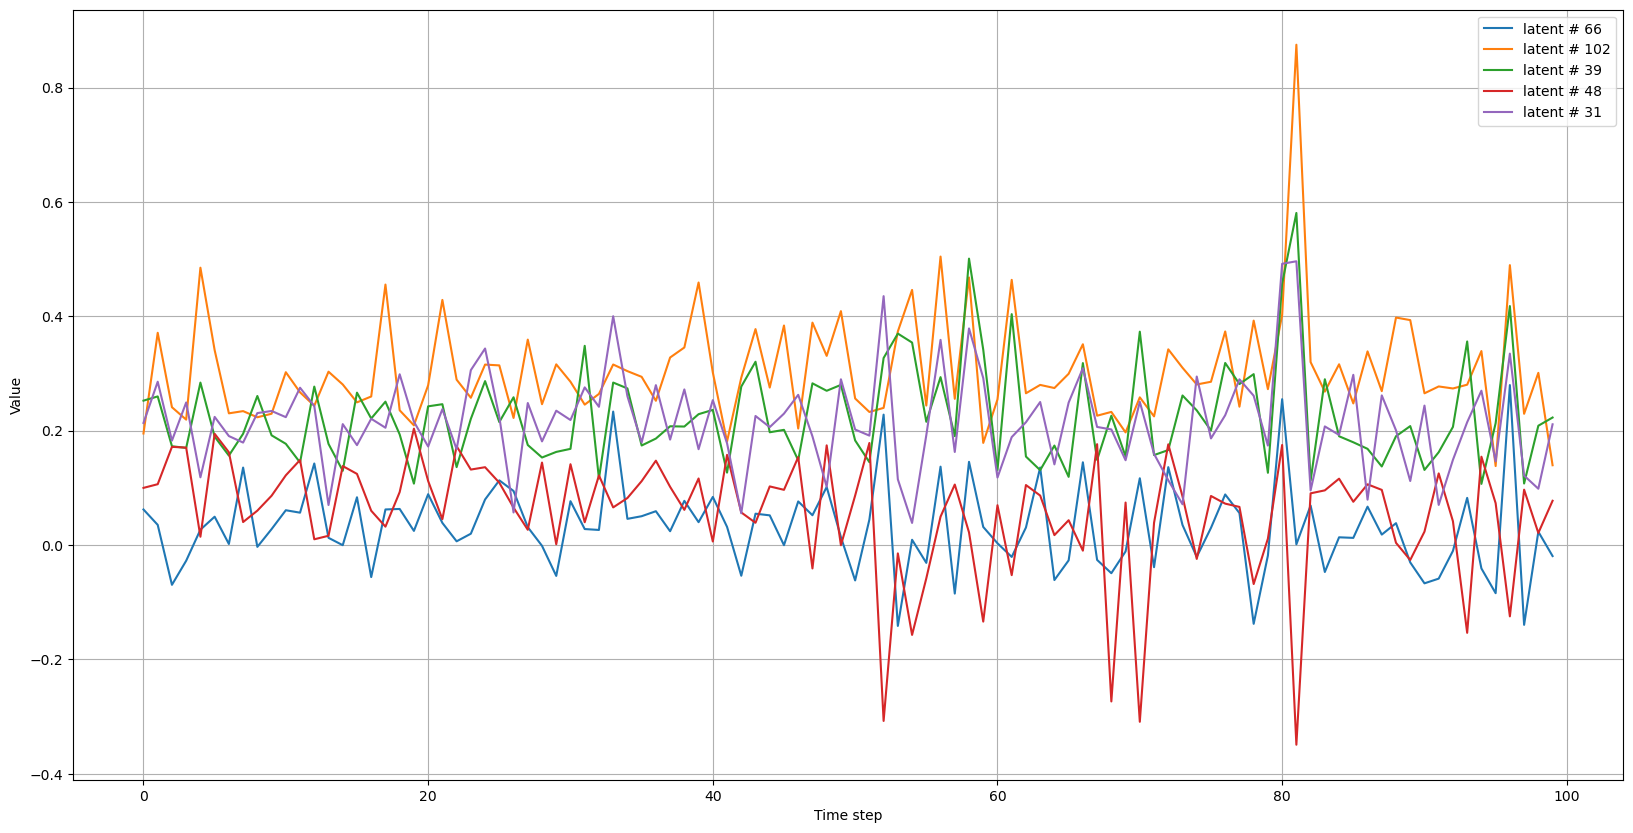

SHAPE: torch.Size([1, 128, 100])


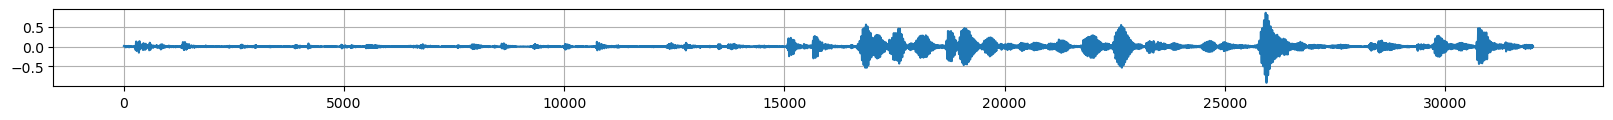

conditioning.shap = torch.Size([100, 1])


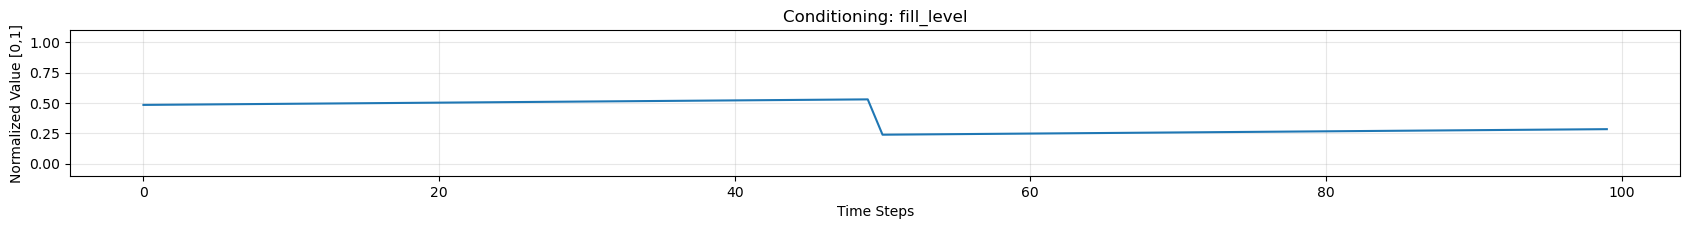

In [8]:
# just show some stuff 
def pmap(x) :
    return 55+x*(88-55)

print("size of dataset is",len(adataset))
print("no. of batches per epoch is", params['batches_per_epoch'])
print("batchsize id  is", params['batch_size'])

samp, target = adataset.rand_sample()  #samp.shape=(T, inputsize+cond_size)
pvect=samp[:, -model_config.cond_size:]
print(f'PVECT - shape is {pvect.shape}')
pvect0=samp[0, -model_config.cond_size:]
print(f"pvect[0]: {pvect0}")
pvect25=samp[25, -model_config.cond_size:]
print(f"pvect[25]: {pvect25}")
pvectl=samp[params['seqLen']-1, -model_config.cond_size:]
print(f"pvect[last]: {pvectl}")

inp=samp[:,:-model_config.cond_size]
print(f'inp.shape is {inp.shape}')

# Now grab n=10 random latent components and look at them over time
_, p = inp.shape
# Generate n=10 random indices from 0 to p-1
indices = torch.randperm(p)[:5]
sub_inp = inp[:, indices]
sub_inp.shape


#first print latent sequence
plt.figure(figsize=(20,10)) 
# plt.plot(np.arange(len(sub_inp)), sub_inp) #just print some example from the batch
# plt.grid()
# plt.show()

ts = np.arange(len(sub_inp))  # time steps
for i in range(sub_inp.shape[1]):   # loop over trajectories
    plt.plot(ts, sub_inp[:, i], label=f"latent # {indices[i]}")
plt.legend()
plt.xlabel("Time step")
plt.ylabel("Value")
plt.grid()
plt.show()



tokens=samp[:, :params['input_size']].T.unsqueeze(0)
print(f"SHAPE: {tokens[:,:params['input_size']].shape}")
audiosamps, sr=latents_to_audio_simple(enc_model, tokens*params['clamp_val'])
audiosamps=audiosamps[0, 0]

plt.figure(figsize=(20,1)) 
plt.plot(audiosamps) #just print one example from the batch
plt.grid()
plt.show()


#conditioning = samp[:,-model_config.cond_size:]
cvect = pvect#=samp[:, -model_config.cond_size:] # samp[:, -model_config.cond_size:].squeeze(0)  #imp_seq[0, :, -len(params['props']):]
n_params = cvect.shape[1]
print(f'conditioning.shap = {cvect.shape}')
# # Additional Analysis: Conditioning parameters over time
if n_params > 0:
    plt.figure(figsize=(17, 4))
    
    param_names = list(data_config.parameter_specs.keys())
    
    for i in range(n_params):
        plt.subplot(2, (n_params + 1) // 2, i + 1)
        plt.plot(cvect[:,i].numpy())
        param_name = param_names[i] if i < len(param_names) else f'param_{i}'
        plt.title(f'Conditioning: {param_name}')
        plt.xlabel('Time Steps')
        plt.ylabel('Normalized Value [0,1]')
        plt.grid(True, alpha=0.3)
        plt.ylim(-0.1, 1.1)
    
    plt.tight_layout()
    plt.show()

    # #print out numbers
    # cvect_mapped = torch.stack([pmap(cvect[:, 0]), cvect[:, 1]], dim=1)
    # print(f"conditioning params: {cvect_mapped}")

#Another check just to see that the ecdc and params are coming from the same file and using the same starting sample number (no using the random sample as above)
# entry = adataset.sequence_map[0]         # (dataset_idx, start_frame, token_file_path)
# ds_idx, start, token_path = entry
# cpath = adataset._cond_path_for(token_path)
# print("codes:", token_path.name, "cond:", cpath.name, "start:", start)


#This is the "rand_samp" plotted above"
Audio(audiosamps, rate=params['sample_rate'])

In [9]:

def prepare_target_codebook_latents(rnn_model, target_codes, scales_bq=None):
    """
    target_codes: (B, n_q) LongTensor for a single timestep
    returns: List[n_q] of (B, D=128) latents, one per codebook (level 0..n_q-1)
    """
    dev = rnn_model._E_eff.device
    codes_bq = target_codes.to(dev, dtype=torch.long, non_blocking=True)
    if scales_bq is not None:
        scales_bq = scales_bq.to(dev, non_blocking=True)

    out = []
    for q in range(rnn_model.n_q):
        E_q = rnn_model._E_eff[q]                    # (K, D)
        e_q = F.embedding(codes_bq[:, q], E_q)       # (B, D)
        if scales_bq is not None:
            e_q = e_q * scales_bq[:, q].unsqueeze(-1)
        out.append(e_q)
    return out

In [10]:
# Define the training cycle (100% teacher forcing for now)
#*************************************

def train(model,encodec_model, epoch):

 model.train() #put in training mode
 ave_loss_over_steps = 0
 debug_seqs=0

 for batch_num, (inp, target) in enumerate(train_loader):
    debug_seqs += len(inp)
    inp, target = inp.to(device), target.to(device)
    
    hidden = model.init_hidden(params['batch_size'])
    optimizer.zero_grad()
    loss = 0
    
    # Initialize per-quantizer loss tracking
    quantizer_losses = [0.0] * params['n_q']
    
    # Define quantizer weights
    quantizer_weights = params['quantizer_weights'][:params['n_q']]
     
    for i in range(params['seqLen']):  # causal: one time step at a time
        if params['simulate_parallel']:
            use_teacher_forcing = True
            # just placeholders for shape when sim-parallel; zeros are fine
            tflatents = [torch.zeros(params['batch_size'], params['input_size'], device=device)
                         for _ in range(params['n_q'])]
        else:
            use_teacher_forcing = use_tf(epoch)
            if use_teacher_forcing:
                # prepare ground-truth per-level latents (List[n_q * (B,128)])
                tflatents = prepare_target_codebook_latents(model, target[:, i, :]) # uses model's decoder
            else:
                tflatents = None
    
        # --- ONE call; ONE set of sampled tokens used everywhere ---
        logits_list, hidden, sampled_indices, step_latent = model(
            inp[:, i, :],
            hidden,
            target_codebook_latents=tflatents,
            use_teacher_forcing=use_teacher_forcing,
            return_step_latent=False, # this is for "self conditioning"

        )
    
        # --- CE loss exactly as before (per-quantizer) ---
        for j in range(params['n_q']):
            quantizer_loss = criterion(logits_list[j], target[:, i, j])
            quantizer_losses[j] += quantizer_loss.item()
            loss = loss + quantizer_weights[j] * quantizer_loss
    
        # # --- Self-conditioning for next step: feed SAME latent forward ---
        # if i + 1 < params['seqLen']:
        #     # step_latent is:
        #     #  - the sum of teacher-forced per-level latents if TF,
        #     #  - the sum of decoded sampled tokens if AR.
        #     # Use .detach() for stable training (no across-time grads for now).
        #     inp[:, i + 1, :params['input_size']] = step_latent.detach()
    
    loss = loss / params['seqLen']
    quantizer_losses = [ql / params['seqLen'] for ql in quantizer_losses]
    
    loss.backward()
    optimizer.step()
    
    ave_loss_per_sample = loss.item()/params['seqLen']   #over each minibatch
    #ave_loss_over_steps += ave_loss_per_sample
    
    # Accumulate quantizer losses over the epoch
    if batch_num == 0:  # Initialize on first batch
        epoch_quantizer_losses = [0.0] * params['n_q']
    
    for j in range(params['n_q']):
        epoch_quantizer_losses[j] += quantizer_losses[j]
    
    if batch_num>=(params['batches_per_epoch']-1):
        break


    per_q_time_mean = [s / params['seqLen'] for s in quantizer_losses]  # each is batch-mean, time-mean
    overall_time_mean = float(torch.dot(quantizer_weights, torch.tensor(per_q_time_mean, device=quantizer_weights.device)).item())

    
 print(f"Finished epoch number {epoch} with a total of {debug_seqs} debug_seqs")
 if (epoch+1) % log_interval == 0:
    print(f" time: {datetime.now()}, epoch {epoch+1},  Loss: {ave_loss_per_sample:.4f}")
    list_of_losses.append(ave_loss_per_sample)
    writer.add_scalar("Loss/train", ave_loss_per_sample, epoch+1)
    writer.add_scalar("overall_time_mean", overall_time_mean, epoch+1)
    
    # Log individual quantizer losses (averaged over the epoch)
    num_batches = min(batch_num + 1, params['batches_per_epoch'])
    for j in range(params['n_q']):
        avg_quantizer_loss = epoch_quantizer_losses[j] / num_batches
        writer.add_scalar(f"Loss/quantizer_{j}", avg_quantizer_loss, epoch+1)
        print(f"  Quantizer {j} Loss: {avg_quantizer_loss:.4f}")

 if (epoch+1) % visualize_interval == 0:

     # these two lines address a resource management issues with temporary directories ...  I think....
     torch.cuda.empty_cache()  # if using GPU
     gc.collect()

     result = newgen(model,max_length)
     print(f'plot the audio which has shape {result.shape}')
     plt.figure(figsize=(20,1))
     plt.plot(np.arange(len(result)), result) #just print one example from the batch
     plt.show()
     model.train() #put model back to training mode


 # overwrite the last, and save a numbered checkpoint
 if (epoch + 1) % params['savemodel_interval'] == 0:
    checkpoint_data = {
        'epoch': epoch+1,
        'model_state_dict': model.state_dict(),
        'optimizer_state_dict': optimizer.state_dict()
    }
    
    # Save numbered checkpoint
    numbered_path = os.path.join(f"{out_dir}/checkpoints", f"checkpoint_{epoch+1}.pt")
    torch.save(checkpoint_data, numbered_path)
    
    # Copy to "last" (much faster than saving twice)
    last_path = os.path.join(f"{out_dir}/checkpoints", "last_checkpoint.pt")
    shutil.copy2(numbered_path, last_path)
    
    print(f"Saved checkpoint at epoch {epoch+1}")

In [11]:
# ---- Create Output Folders ----
if resume_checkpoint != None:
    out_dir = resume_checkpoint
else:
    run_timestamp = datetime.now().strftime("%Y%m%d_%H%M%S")
    out_dir = os.path.join(params['savemodeldir'], run_timestamp + "_"+savename)
    os.makedirs(out_dir, exist_ok=True)

    os.makedirs(out_dir, exist_ok=True)
    os.makedirs(f"{out_dir}/checkpoints", exist_ok=True)
    os.makedirs(f"{out_dir}/tensorboard", exist_ok=True)

save_run_config(f"{out_dir}/config_v2.pt", params=None, model_config=model_config, data_config=data_config)
print(f"wrote {out_dir}/config_v2.pt")

saved to D:\temp\test2\RNeNcodec\dev_notebooks\output\20260128_231114_water_soft.newenvtest\config_v2.pt
wrote json param file
wrote D:\temp\test2\RNeNcodec\dev_notebooks\output\20260128_231114_water_soft.newenvtest/config_v2.pt


In [12]:
import copy
from rnencodec.generator import RNNGenerator

inference_model_config=copy.deepcopy(model_config)
inference_model_config.cascade='hard' # 
inference_model_config.hard_sample_mode="sample"
inference_model_config.top_n_hard=12
inference_model_config.temperature_hard=1.0


def newgen(model,max_length):
    #This hack allows us to "configure" the model for generation differently - in particular how it is sampled (which may be different from how it is trained)
    inference_model = rnencodec.model.gru_audio_model.RNN(model_config, enc_model).to('cpu')
    inference_model.load_state_dict(model.state_dict())

    #override these values of state
    inference_model.cascade='hard' # 
    inference_model.hard_sample_mode="sample"
    inference_model.top_n_hard=12
    inference_model.temperature_hard=1.0



    rnninference=RNNGenerator(inference_model, inference_model_config, testdata_config, enc_model, max_length, max_length)
    
    # grab a random conditioning vector from the data set
    p_inp, _ = next(iter(test_loader)) # don't need targets
    c = p_inp[:, 0, -inference_model_config.cond_size:].squeeze(0).to(device) #grab a random input sequence
    print(f'DEVICE going in: model tensors {next(model.parameters()).device}, enc_model {enc_model.device}, c {c.device}')
    print(f'About toInitialize generator with c.shape = {c.shape}') 
    rnninference.warmup(c,10)
    gen = rnninference.getNextAudioHop(c, hop=max_length)
    
    return gen

In [13]:
inference_model_config

GRUModelConfig(input_size=128, cond_size=1, hidden_size=128, num_layers=3, n_q=8, codebook_size=1024, dropout=0.1, inp_proportion=5, cond_proportion=2, gumbel_tau_start=1.0, gumbel_tau_end=0.5, straight_through=True, cascade='hard', hard_sample_mode='sample', top_n_hard=12, temperature_hard=1.0, tau_soft=0.35, top_n_soft=8)

### Load the model 

In [14]:

rnn = rnencodec.model.gru_audio_model.RNN(model_config, enc_model).to(device)
    
optimizer = torch.optim.Adam(rnn.parameters(), lr=params['lr'])
criterion = nn.CrossEntropyLoss(reduction='mean')

start_epoch=0

if resume_checkpoint:
    checkpoint_path = os.path.join(f"{out_dir}/checkpoints", "last_checkpoint.pt")
    assert os.path.exists(checkpoint_path), f"File {checkpoint_path} does not exist"
    checkpoint = torch.load(checkpoint_path)
    rnn.load_state_dict(checkpoint['model_state_dict'])
    optimizer.load_state_dict(checkpoint['optimizer_state_dict'])
    start_epoch = checkpoint['epoch'] + 1
    print(f"Resumed from checkpoint at epoch {start_epoch}")

writer = SummaryWriter(log_dir=f"{out_dir}/tensorboard")

Latents embedded in 91 of the GRU input size of 128
Conditioning parameters embedded in 37 of the GRU input size of 128


In [15]:
num_trainable_params = sum(p.numel() for p in rnn.parameters() if p.requires_grad)
print(f"Total trainable parameters: {num_trainable_params}")

bd = param_breakdown(rnn, trainable_only=True) #prints out a breakdown of the parameter counts per layter
# pretty print
print(f"latent_proj: {bd['latent_proj']:,}")
print(f"cond_proj:   {bd['cond_proj']:,}")
print(f"GRU total:   {bd['gru_total']:,}")
for k, v in bd['gru_layers'].items():
    print(f"  {k}: {v:,}")
print("Decoders (per head):")
for i, n in enumerate(bd['decoders']):
    print(f"  decoder[{i}]: {n:,}")
print(f"Decoders total: {bd['decoders_total']:,}")
print(f"Model total:    {bd['model_total']:,}")


n_q, K, D = rnn._E_eff.shape
print(f"✅ E_eff is built: n_q={n_q}, K={K}, D={D}, device={rnn._E_eff.device}")
# per-level shapes (each should be (K, D))
print("Per-level shapes:", [tuple(rnn._E_eff[q].shape) for q in range(n_q)])


# 1) Make sure both models are on the same device
device = next(rnn.parameters()).device
enc_model = enc_model.to(device)

B, T = 4, 7
codes = torch.randint(0, rnn.codebook_size, (B, T, rnn.n_q), device=device, dtype=torch.long)

# 3) Manual path via cached effective tables (matches Encodec exactly)
z_manual = rnn._codes_to_latent_sum(codes)                           # (B, T, D)

# 4) Encodec path (expects (n_q, B, T))
z_decode = enc_model.quantizer.decode(codes.permute(2, 0, 1))        # (B, D, T)
z_decode = z_decode.permute(0, 2, 1).contiguous()                    # (B, T, D)

# 5) Compare
diff = (z_manual - z_decode).abs()
print("DIFFERENCE — max|Δ|=", diff.max().item(), "mean|Δ|=", diff.mean().item())

Total trainable parameters: 2414373
latent_proj: 11,739
cond_proj:   74
GRU total:   297,216
  l0/fwd: 99,072
  l1/fwd: 99,072
  l2/fwd: 99,072
Decoders (per head):
  decoder[0]: 263,168
  decoder[1]: 263,168
  decoder[2]: 263,168
  decoder[3]: 263,168
  decoder[4]: 263,168
  decoder[5]: 263,168
  decoder[6]: 263,168
  decoder[7]: 263,168
Decoders total: 2,105,344
Model total:    2,414,373
✅ E_eff is built: n_q=8, K=1024, D=128, device=cpu
Per-level shapes: [(1024, 128), (1024, 128), (1024, 128), (1024, 128), (1024, 128), (1024, 128), (1024, 128), (1024, 128)]
DIFFERENCE — max|Δ|= 0.0 mean|Δ|= 0.0


2026-01-28 23:11:18 Starting training...
Finished epoch number 0 with a total of 10000 debug_seqs
 time: 2026-01-28 23:16:10.668296, epoch 1,  Loss: 0.3786
  Quantizer 0 Loss: 4.6421
  Quantizer 1 Loss: 4.8890
  Quantizer 2 Loss: 5.1075
  Quantizer 3 Loss: 5.2186
  Quantizer 4 Loss: 5.3779
  Quantizer 5 Loss: 5.5314
  Quantizer 6 Loss: 5.6355
  Quantizer 7 Loss: 5.7086
Latents embedded in 91 of the GRU input size of 128
Conditioning parameters embedded in 37 of the GRU input size of 128
DEVICE going in: model tensors cpu, enc_model cpu, c cpu
About toInitialize generator with c.shape = torch.Size([1])
params_seq.shape = torch.Size([10, 1])


D:\temp\test2\RNeNcodec\rnencodec\generator\generator.py:163: UserWarning: Warning: ....... chunk size 300 is <= hop size 300. RETURNING full hop and continuing
  warnings.warn(f"Warning: ....... chunk size {T} is <= hop size {h}. RETURNING full hop and continuing")


plot the audio which has shape (96000,)


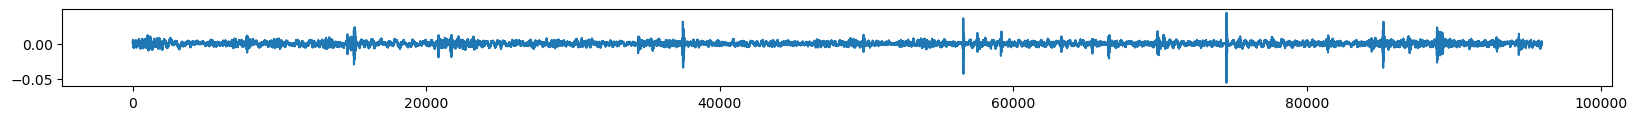

Finished epoch number 1 with a total of 10000 debug_seqs
 time: 2026-01-28 23:20:37.767853, epoch 2,  Loss: 0.3520
  Quantizer 0 Loss: 4.2322
  Quantizer 1 Loss: 4.3528
  Quantizer 2 Loss: 4.5298
  Quantizer 3 Loss: 4.5750
  Quantizer 4 Loss: 4.6960
  Quantizer 5 Loss: 4.8028
  Quantizer 6 Loss: 4.8964
  Quantizer 7 Loss: 4.9712
Latents embedded in 91 of the GRU input size of 128
Conditioning parameters embedded in 37 of the GRU input size of 128
DEVICE going in: model tensors cpu, enc_model cpu, c cpu
About toInitialize generator with c.shape = torch.Size([1])
params_seq.shape = torch.Size([10, 1])
plot the audio which has shape (96000,)


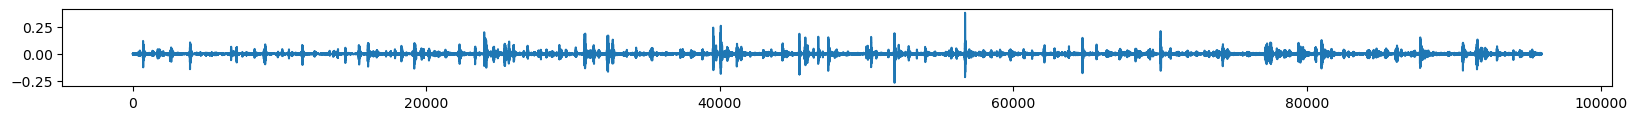

Finished epoch number 2 with a total of 10000 debug_seqs
 time: 2026-01-28 23:25:10.812059, epoch 3,  Loss: 0.3348
  Quantizer 0 Loss: 4.1075
  Quantizer 1 Loss: 4.1631
  Quantizer 2 Loss: 4.2839
  Quantizer 3 Loss: 4.2871
  Quantizer 4 Loss: 4.3786
  Quantizer 5 Loss: 4.4551
  Quantizer 6 Loss: 4.5302
  Quantizer 7 Loss: 4.6048
Latents embedded in 91 of the GRU input size of 128
Conditioning parameters embedded in 37 of the GRU input size of 128
DEVICE going in: model tensors cpu, enc_model cpu, c cpu
About toInitialize generator with c.shape = torch.Size([1])
params_seq.shape = torch.Size([10, 1])
plot the audio which has shape (96000,)


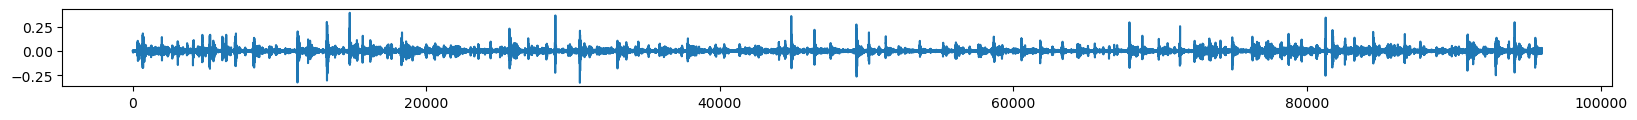

Finished epoch number 3 with a total of 10000 debug_seqs
 time: 2026-01-28 23:29:54.921219, epoch 4,  Loss: 0.3198
  Quantizer 0 Loss: 4.0121
  Quantizer 1 Loss: 4.0204
  Quantizer 2 Loss: 4.0965
  Quantizer 3 Loss: 4.0690
  Quantizer 4 Loss: 4.1329
  Quantizer 5 Loss: 4.1758
  Quantizer 6 Loss: 4.2336
  Quantizer 7 Loss: 4.2963
Latents embedded in 91 of the GRU input size of 128
Conditioning parameters embedded in 37 of the GRU input size of 128
DEVICE going in: model tensors cpu, enc_model cpu, c cpu
About toInitialize generator with c.shape = torch.Size([1])
params_seq.shape = torch.Size([10, 1])
plot the audio which has shape (96000,)


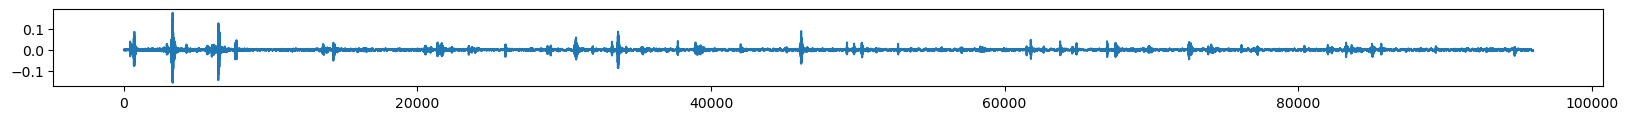

Finished epoch number 4 with a total of 10000 debug_seqs
 time: 2026-01-28 23:34:40.474346, epoch 5,  Loss: 0.3097
  Quantizer 0 Loss: 3.9378
  Quantizer 1 Loss: 3.9209
  Quantizer 2 Loss: 3.9577
  Quantizer 3 Loss: 3.9044
  Quantizer 4 Loss: 3.9517
  Quantizer 5 Loss: 3.9748
  Quantizer 6 Loss: 4.0114
  Quantizer 7 Loss: 4.0678
Latents embedded in 91 of the GRU input size of 128
Conditioning parameters embedded in 37 of the GRU input size of 128
DEVICE going in: model tensors cpu, enc_model cpu, c cpu
About toInitialize generator with c.shape = torch.Size([1])
params_seq.shape = torch.Size([10, 1])
plot the audio which has shape (96000,)


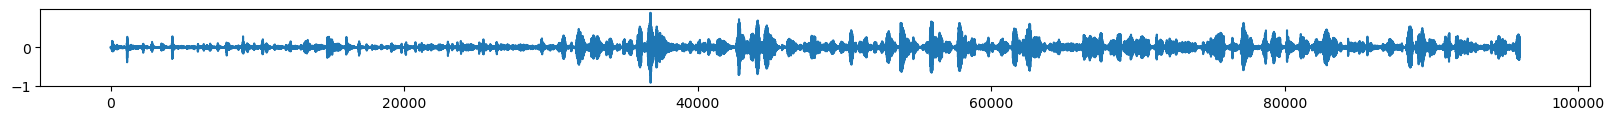

Finished epoch number 5 with a total of 10000 debug_seqs
 time: 2026-01-28 23:39:26.106157, epoch 6,  Loss: 0.3036
  Quantizer 0 Loss: 3.8669
  Quantizer 1 Loss: 3.8250
  Quantizer 2 Loss: 3.8455
  Quantizer 3 Loss: 3.7787
  Quantizer 4 Loss: 3.8037
  Quantizer 5 Loss: 3.8146
  Quantizer 6 Loss: 3.8418
  Quantizer 7 Loss: 3.8914
Latents embedded in 91 of the GRU input size of 128
Conditioning parameters embedded in 37 of the GRU input size of 128
DEVICE going in: model tensors cpu, enc_model cpu, c cpu
About toInitialize generator with c.shape = torch.Size([1])
params_seq.shape = torch.Size([10, 1])
plot the audio which has shape (96000,)


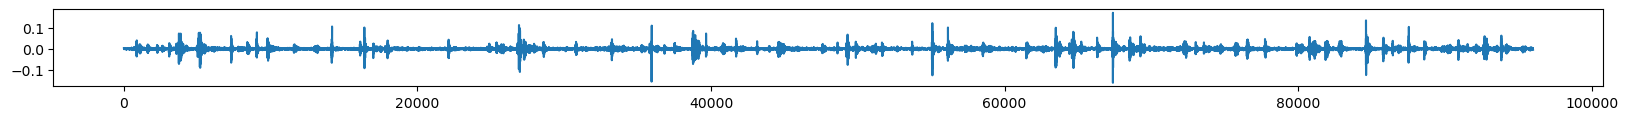

Finished epoch number 6 with a total of 10000 debug_seqs
 time: 2026-01-28 23:44:19.781138, epoch 7,  Loss: 0.2924
  Quantizer 0 Loss: 3.7954
  Quantizer 1 Loss: 3.7317
  Quantizer 2 Loss: 3.7425
  Quantizer 3 Loss: 3.6667
  Quantizer 4 Loss: 3.6849
  Quantizer 5 Loss: 3.6825
  Quantizer 6 Loss: 3.6991
  Quantizer 7 Loss: 3.7487
Latents embedded in 91 of the GRU input size of 128
Conditioning parameters embedded in 37 of the GRU input size of 128
DEVICE going in: model tensors cpu, enc_model cpu, c cpu
About toInitialize generator with c.shape = torch.Size([1])
params_seq.shape = torch.Size([10, 1])
plot the audio which has shape (96000,)


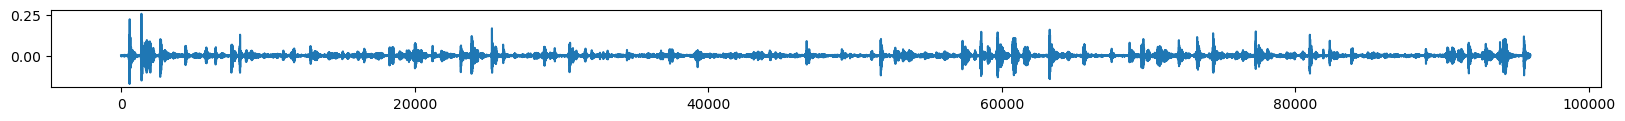

Finished epoch number 7 with a total of 10000 debug_seqs
 time: 2026-01-28 23:49:07.413309, epoch 8,  Loss: 0.2869
  Quantizer 0 Loss: 3.7296
  Quantizer 1 Loss: 3.6506
  Quantizer 2 Loss: 3.6548
  Quantizer 3 Loss: 3.5693
  Quantizer 4 Loss: 3.5813
  Quantizer 5 Loss: 3.5725
  Quantizer 6 Loss: 3.5757
  Quantizer 7 Loss: 3.6287
Latents embedded in 91 of the GRU input size of 128
Conditioning parameters embedded in 37 of the GRU input size of 128
DEVICE going in: model tensors cpu, enc_model cpu, c cpu
About toInitialize generator with c.shape = torch.Size([1])
params_seq.shape = torch.Size([10, 1])
plot the audio which has shape (96000,)


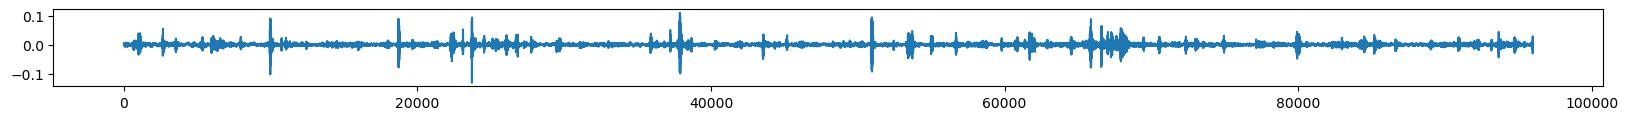

Finished epoch number 8 with a total of 10000 debug_seqs
 time: 2026-01-28 23:54:01.988947, epoch 9,  Loss: 0.2835
  Quantizer 0 Loss: 3.6734
  Quantizer 1 Loss: 3.5804
  Quantizer 2 Loss: 3.5719
  Quantizer 3 Loss: 3.4863
  Quantizer 4 Loss: 3.4909
  Quantizer 5 Loss: 3.4726
  Quantizer 6 Loss: 3.4783
  Quantizer 7 Loss: 3.5243
Latents embedded in 91 of the GRU input size of 128
Conditioning parameters embedded in 37 of the GRU input size of 128
DEVICE going in: model tensors cpu, enc_model cpu, c cpu
About toInitialize generator with c.shape = torch.Size([1])
params_seq.shape = torch.Size([10, 1])
plot the audio which has shape (96000,)


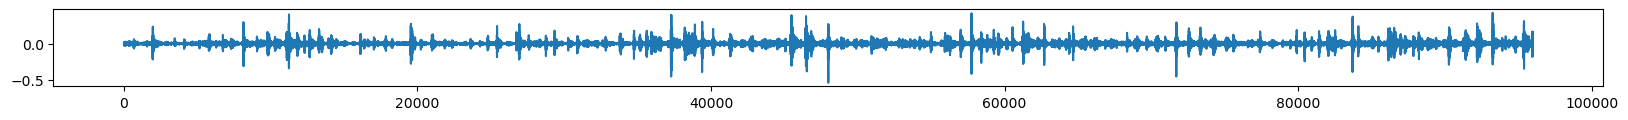

Finished epoch number 9 with a total of 10000 debug_seqs
 time: 2026-01-28 23:58:56.337910, epoch 10,  Loss: 0.2771
  Quantizer 0 Loss: 3.6250
  Quantizer 1 Loss: 3.5191
  Quantizer 2 Loss: 3.5048
  Quantizer 3 Loss: 3.4141
  Quantizer 4 Loss: 3.4165
  Quantizer 5 Loss: 3.3911
  Quantizer 6 Loss: 3.3897
  Quantizer 7 Loss: 3.4378
Latents embedded in 91 of the GRU input size of 128
Conditioning parameters embedded in 37 of the GRU input size of 128
DEVICE going in: model tensors cpu, enc_model cpu, c cpu
About toInitialize generator with c.shape = torch.Size([1])
params_seq.shape = torch.Size([10, 1])
plot the audio which has shape (96000,)


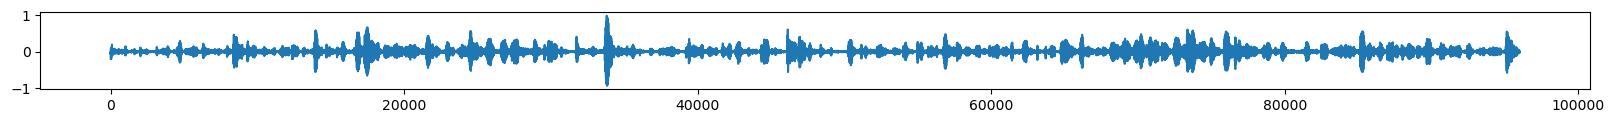

Finished epoch number 10 with a total of 10000 debug_seqs
 time: 2026-01-29 00:03:51.429772, epoch 11,  Loss: 0.2722
  Quantizer 0 Loss: 3.5770
  Quantizer 1 Loss: 3.4605
  Quantizer 2 Loss: 3.4422
  Quantizer 3 Loss: 3.3456
  Quantizer 4 Loss: 3.3495
  Quantizer 5 Loss: 3.3181
  Quantizer 6 Loss: 3.3109
  Quantizer 7 Loss: 3.3604
Latents embedded in 91 of the GRU input size of 128
Conditioning parameters embedded in 37 of the GRU input size of 128
DEVICE going in: model tensors cpu, enc_model cpu, c cpu
About toInitialize generator with c.shape = torch.Size([1])
params_seq.shape = torch.Size([10, 1])
plot the audio which has shape (96000,)


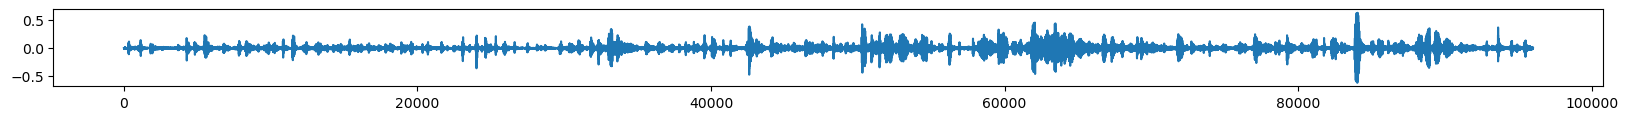

Finished epoch number 11 with a total of 10000 debug_seqs
 time: 2026-01-29 00:08:44.481184, epoch 12,  Loss: 0.2688
  Quantizer 0 Loss: 3.5305
  Quantizer 1 Loss: 3.4054
  Quantizer 2 Loss: 3.3788
  Quantizer 3 Loss: 3.2840
  Quantizer 4 Loss: 3.2821
  Quantizer 5 Loss: 3.2496
  Quantizer 6 Loss: 3.2414
  Quantizer 7 Loss: 3.2864
Latents embedded in 91 of the GRU input size of 128
Conditioning parameters embedded in 37 of the GRU input size of 128
DEVICE going in: model tensors cpu, enc_model cpu, c cpu
About toInitialize generator with c.shape = torch.Size([1])
params_seq.shape = torch.Size([10, 1])
plot the audio which has shape (96000,)


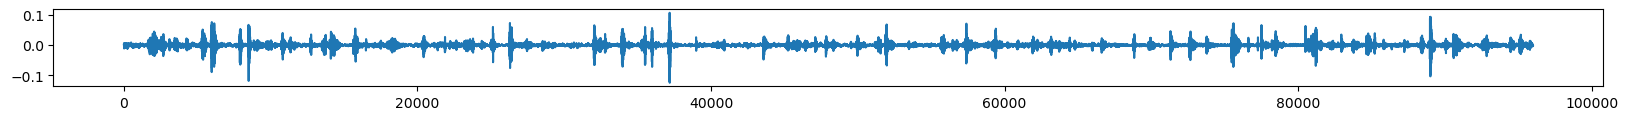

Finished epoch number 12 with a total of 10000 debug_seqs
 time: 2026-01-29 00:13:32.549627, epoch 13,  Loss: 0.2651
  Quantizer 0 Loss: 3.4888
  Quantizer 1 Loss: 3.3455
  Quantizer 2 Loss: 3.3174
  Quantizer 3 Loss: 3.2274
  Quantizer 4 Loss: 3.2248
  Quantizer 5 Loss: 3.1854
  Quantizer 6 Loss: 3.1721
  Quantizer 7 Loss: 3.2251
Latents embedded in 91 of the GRU input size of 128
Conditioning parameters embedded in 37 of the GRU input size of 128
DEVICE going in: model tensors cpu, enc_model cpu, c cpu
About toInitialize generator with c.shape = torch.Size([1])
params_seq.shape = torch.Size([10, 1])
plot the audio which has shape (96000,)


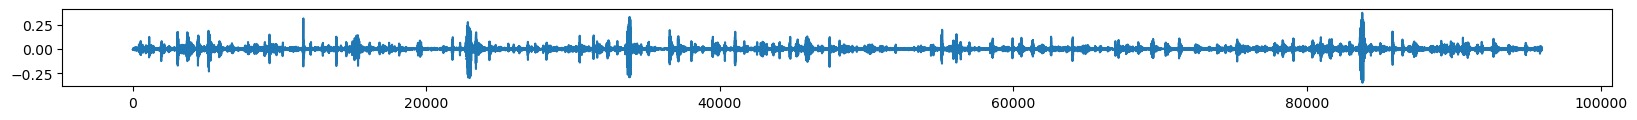

Finished epoch number 13 with a total of 10000 debug_seqs
 time: 2026-01-29 00:18:17.856105, epoch 14,  Loss: 0.2568
  Quantizer 0 Loss: 3.4591
  Quantizer 1 Loss: 3.3118
  Quantizer 2 Loss: 3.2833
  Quantizer 3 Loss: 3.1852
  Quantizer 4 Loss: 3.1821
  Quantizer 5 Loss: 3.1433
  Quantizer 6 Loss: 3.1269
  Quantizer 7 Loss: 3.1793
Latents embedded in 91 of the GRU input size of 128
Conditioning parameters embedded in 37 of the GRU input size of 128
DEVICE going in: model tensors cpu, enc_model cpu, c cpu
About toInitialize generator with c.shape = torch.Size([1])
params_seq.shape = torch.Size([10, 1])
plot the audio which has shape (96000,)


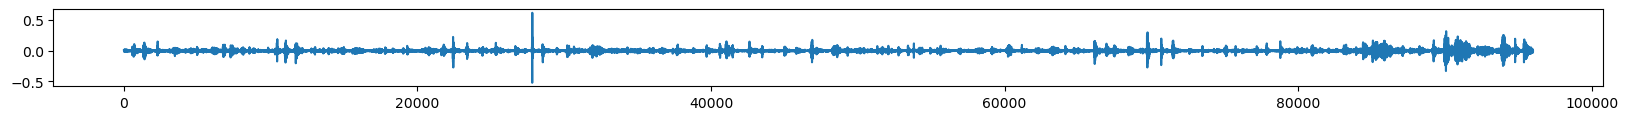

Finished epoch number 14 with a total of 10000 debug_seqs
 time: 2026-01-29 00:23:05.756695, epoch 15,  Loss: 0.2526
  Quantizer 0 Loss: 3.4170
  Quantizer 1 Loss: 3.2610
  Quantizer 2 Loss: 3.2255
  Quantizer 3 Loss: 3.1314
  Quantizer 4 Loss: 3.1295
  Quantizer 5 Loss: 3.0866
  Quantizer 6 Loss: 3.0691
  Quantizer 7 Loss: 3.1217
Latents embedded in 91 of the GRU input size of 128
Conditioning parameters embedded in 37 of the GRU input size of 128
DEVICE going in: model tensors cpu, enc_model cpu, c cpu
About toInitialize generator with c.shape = torch.Size([1])
params_seq.shape = torch.Size([10, 1])
plot the audio which has shape (96000,)


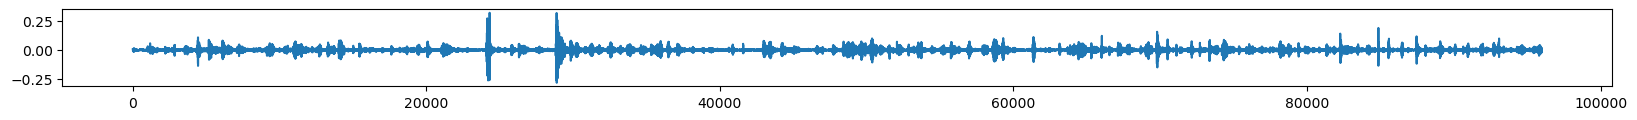

Finished epoch number 15 with a total of 10000 debug_seqs
 time: 2026-01-29 00:27:56.106133, epoch 16,  Loss: 0.2531
  Quantizer 0 Loss: 3.3861
  Quantizer 1 Loss: 3.2235
  Quantizer 2 Loss: 3.1852
  Quantizer 3 Loss: 3.0902
  Quantizer 4 Loss: 3.0900
  Quantizer 5 Loss: 3.0483
  Quantizer 6 Loss: 3.0284
  Quantizer 7 Loss: 3.0829
Latents embedded in 91 of the GRU input size of 128
Conditioning parameters embedded in 37 of the GRU input size of 128
DEVICE going in: model tensors cpu, enc_model cpu, c cpu
About toInitialize generator with c.shape = torch.Size([1])
params_seq.shape = torch.Size([10, 1])
plot the audio which has shape (96000,)


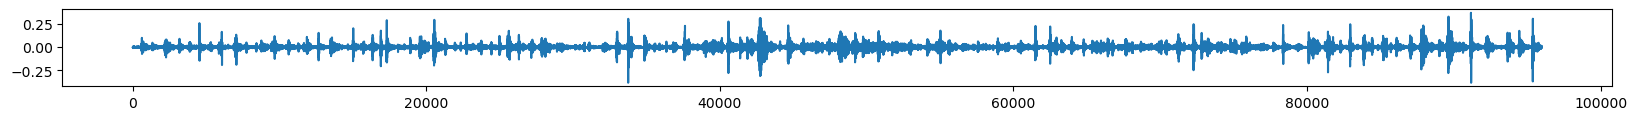

Finished epoch number 16 with a total of 10000 debug_seqs
 time: 2026-01-29 00:32:31.959732, epoch 17,  Loss: 0.2465
  Quantizer 0 Loss: 3.3478
  Quantizer 1 Loss: 3.1779
  Quantizer 2 Loss: 3.1423
  Quantizer 3 Loss: 3.0442
  Quantizer 4 Loss: 3.0454
  Quantizer 5 Loss: 2.9985
  Quantizer 6 Loss: 2.9743
  Quantizer 7 Loss: 3.0292
Latents embedded in 91 of the GRU input size of 128
Conditioning parameters embedded in 37 of the GRU input size of 128
DEVICE going in: model tensors cpu, enc_model cpu, c cpu
About toInitialize generator with c.shape = torch.Size([1])
params_seq.shape = torch.Size([10, 1])
plot the audio which has shape (96000,)


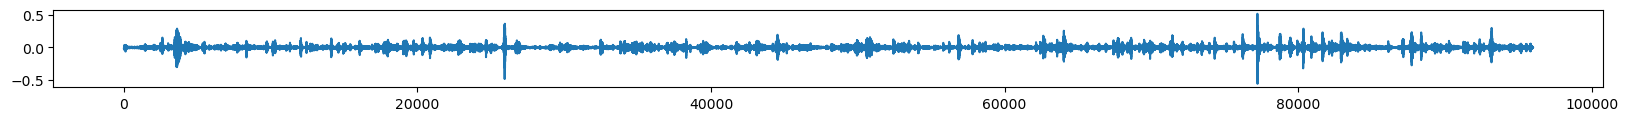

Finished epoch number 17 with a total of 10000 debug_seqs
 time: 2026-01-29 00:37:15.194613, epoch 18,  Loss: 0.2490
  Quantizer 0 Loss: 3.3190
  Quantizer 1 Loss: 3.1426
  Quantizer 2 Loss: 3.1001
  Quantizer 3 Loss: 3.0082
  Quantizer 4 Loss: 3.0086
  Quantizer 5 Loss: 2.9567
  Quantizer 6 Loss: 2.9390
  Quantizer 7 Loss: 2.9904
Latents embedded in 91 of the GRU input size of 128
Conditioning parameters embedded in 37 of the GRU input size of 128
DEVICE going in: model tensors cpu, enc_model cpu, c cpu
About toInitialize generator with c.shape = torch.Size([1])
params_seq.shape = torch.Size([10, 1])
plot the audio which has shape (96000,)


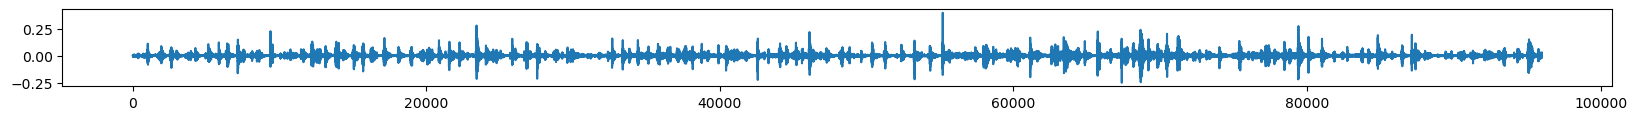

Finished epoch number 18 with a total of 10000 debug_seqs
 time: 2026-01-29 00:42:03.452684, epoch 19,  Loss: 0.2416
  Quantizer 0 Loss: 3.2954
  Quantizer 1 Loss: 3.1148
  Quantizer 2 Loss: 3.0700
  Quantizer 3 Loss: 2.9746
  Quantizer 4 Loss: 2.9781
  Quantizer 5 Loss: 2.9264
  Quantizer 6 Loss: 2.9073
  Quantizer 7 Loss: 2.9574
Latents embedded in 91 of the GRU input size of 128
Conditioning parameters embedded in 37 of the GRU input size of 128
DEVICE going in: model tensors cpu, enc_model cpu, c cpu
About toInitialize generator with c.shape = torch.Size([1])
params_seq.shape = torch.Size([10, 1])
plot the audio which has shape (96000,)


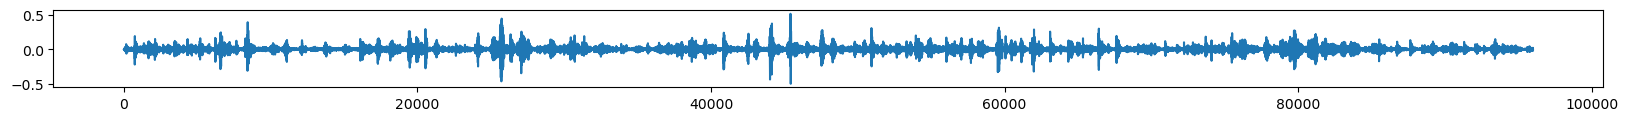

Finished epoch number 19 with a total of 10000 debug_seqs
 time: 2026-01-29 00:46:32.712030, epoch 20,  Loss: 0.2405
  Quantizer 0 Loss: 3.2680
  Quantizer 1 Loss: 3.0833
  Quantizer 2 Loss: 3.0350
  Quantizer 3 Loss: 2.9424
  Quantizer 4 Loss: 2.9436
  Quantizer 5 Loss: 2.8921
  Quantizer 6 Loss: 2.8672
  Quantizer 7 Loss: 2.9244
Latents embedded in 91 of the GRU input size of 128
Conditioning parameters embedded in 37 of the GRU input size of 128
DEVICE going in: model tensors cpu, enc_model cpu, c cpu
About toInitialize generator with c.shape = torch.Size([1])
params_seq.shape = torch.Size([10, 1])
plot the audio which has shape (96000,)


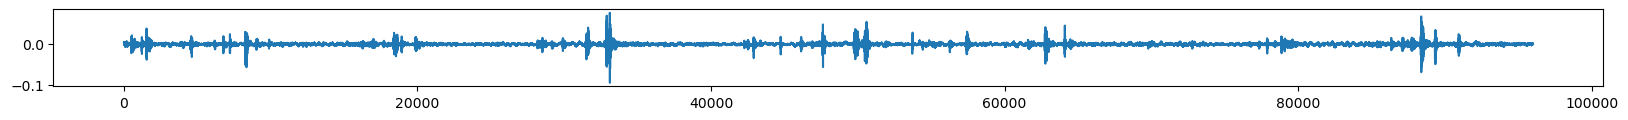

Finished epoch number 20 with a total of 10000 debug_seqs
 time: 2026-01-29 00:51:09.588754, epoch 21,  Loss: 0.2379
  Quantizer 0 Loss: 3.2519
  Quantizer 1 Loss: 3.0535
  Quantizer 2 Loss: 3.0081
  Quantizer 3 Loss: 2.9188
  Quantizer 4 Loss: 2.9193
  Quantizer 5 Loss: 2.8661
  Quantizer 6 Loss: 2.8394
  Quantizer 7 Loss: 2.8996
Latents embedded in 91 of the GRU input size of 128
Conditioning parameters embedded in 37 of the GRU input size of 128
DEVICE going in: model tensors cpu, enc_model cpu, c cpu
About toInitialize generator with c.shape = torch.Size([1])
params_seq.shape = torch.Size([10, 1])
plot the audio which has shape (96000,)


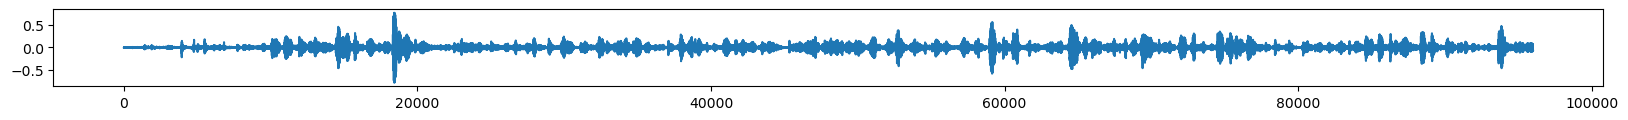

Finished epoch number 21 with a total of 10000 debug_seqs
 time: 2026-01-29 00:55:54.214877, epoch 22,  Loss: 0.2423
  Quantizer 0 Loss: 3.2237
  Quantizer 1 Loss: 3.0225
  Quantizer 2 Loss: 2.9787
  Quantizer 3 Loss: 2.8828
  Quantizer 4 Loss: 2.8905
  Quantizer 5 Loss: 2.8359
  Quantizer 6 Loss: 2.8094
  Quantizer 7 Loss: 2.8701
Latents embedded in 91 of the GRU input size of 128
Conditioning parameters embedded in 37 of the GRU input size of 128
DEVICE going in: model tensors cpu, enc_model cpu, c cpu
About toInitialize generator with c.shape = torch.Size([1])
params_seq.shape = torch.Size([10, 1])
plot the audio which has shape (96000,)


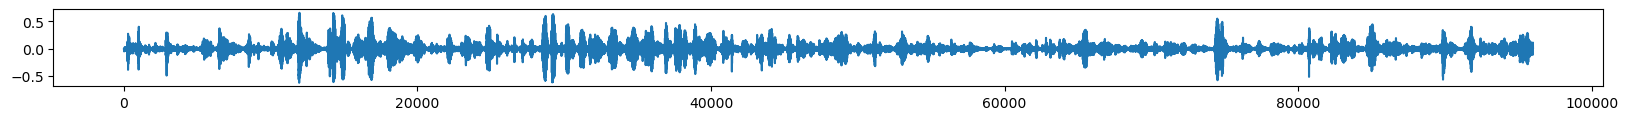

Finished epoch number 22 with a total of 10000 debug_seqs
 time: 2026-01-29 01:00:33.262817, epoch 23,  Loss: 0.2335
  Quantizer 0 Loss: 3.2018
  Quantizer 1 Loss: 2.9918
  Quantizer 2 Loss: 2.9456
  Quantizer 3 Loss: 2.8547
  Quantizer 4 Loss: 2.8643
  Quantizer 5 Loss: 2.8048
  Quantizer 6 Loss: 2.7797
  Quantizer 7 Loss: 2.8407
Latents embedded in 91 of the GRU input size of 128
Conditioning parameters embedded in 37 of the GRU input size of 128
DEVICE going in: model tensors cpu, enc_model cpu, c cpu
About toInitialize generator with c.shape = torch.Size([1])
params_seq.shape = torch.Size([10, 1])
plot the audio which has shape (96000,)


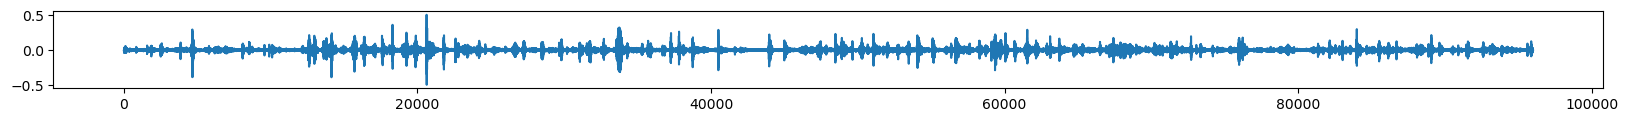

Finished epoch number 23 with a total of 10000 debug_seqs
 time: 2026-01-29 01:05:10.339992, epoch 24,  Loss: 0.2385
  Quantizer 0 Loss: 3.1778
  Quantizer 1 Loss: 2.9684
  Quantizer 2 Loss: 2.9235
  Quantizer 3 Loss: 2.8323
  Quantizer 4 Loss: 2.8343
  Quantizer 5 Loss: 2.7842
  Quantizer 6 Loss: 2.7553
  Quantizer 7 Loss: 2.8158
Latents embedded in 91 of the GRU input size of 128
Conditioning parameters embedded in 37 of the GRU input size of 128
DEVICE going in: model tensors cpu, enc_model cpu, c cpu
About toInitialize generator with c.shape = torch.Size([1])
params_seq.shape = torch.Size([10, 1])
plot the audio which has shape (96000,)


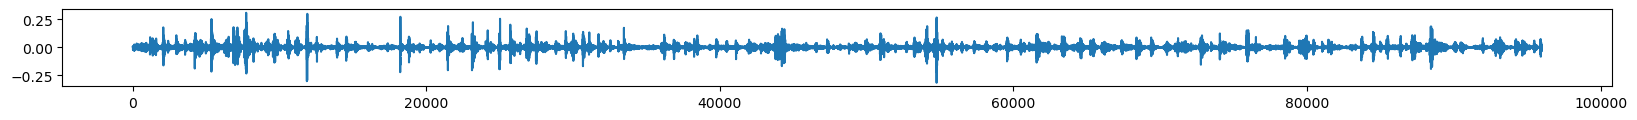

Finished epoch number 24 with a total of 10000 debug_seqs
 time: 2026-01-29 01:09:47.731099, epoch 25,  Loss: 0.2320
  Quantizer 0 Loss: 3.1652
  Quantizer 1 Loss: 2.9530
  Quantizer 2 Loss: 2.9072
  Quantizer 3 Loss: 2.8158
  Quantizer 4 Loss: 2.8251
  Quantizer 5 Loss: 2.7693
  Quantizer 6 Loss: 2.7459
  Quantizer 7 Loss: 2.8034
Latents embedded in 91 of the GRU input size of 128
Conditioning parameters embedded in 37 of the GRU input size of 128
DEVICE going in: model tensors cpu, enc_model cpu, c cpu
About toInitialize generator with c.shape = torch.Size([1])
params_seq.shape = torch.Size([10, 1])
plot the audio which has shape (96000,)


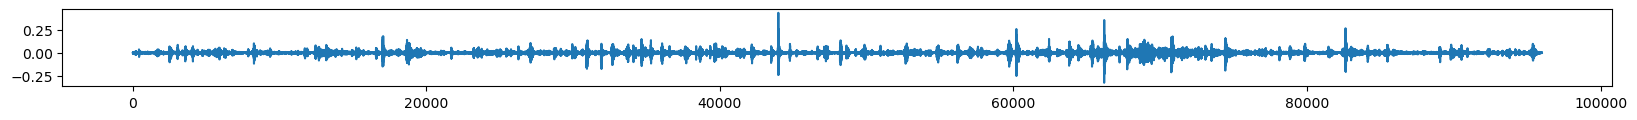

Saved checkpoint at epoch 25
Finished epoch number 25 with a total of 10000 debug_seqs
 time: 2026-01-29 01:16:24.517219, epoch 26,  Loss: 0.3532
  Quantizer 0 Loss: 3.7296
  Quantizer 1 Loss: 6.6274
  Quantizer 2 Loss: 5.7749
  Quantizer 3 Loss: 5.5015
  Quantizer 4 Loss: 5.4410
  Quantizer 5 Loss: 5.4532
  Quantizer 6 Loss: 5.4867
  Quantizer 7 Loss: 5.5297
Latents embedded in 91 of the GRU input size of 128
Conditioning parameters embedded in 37 of the GRU input size of 128
DEVICE going in: model tensors cpu, enc_model cpu, c cpu
About toInitialize generator with c.shape = torch.Size([1])
params_seq.shape = torch.Size([10, 1])
plot the audio which has shape (96000,)


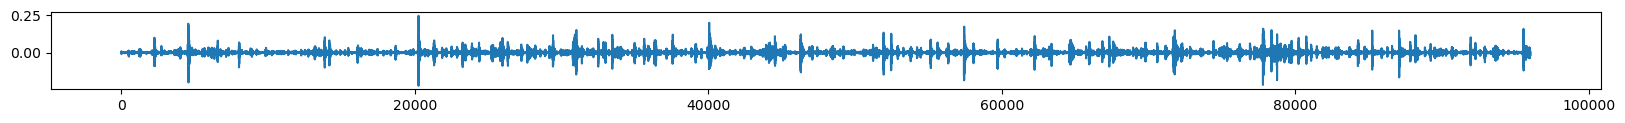

Finished epoch number 26 with a total of 10000 debug_seqs
 time: 2026-01-29 01:23:00.605764, epoch 27,  Loss: 0.3137
  Quantizer 0 Loss: 3.3780
  Quantizer 1 Loss: 3.9368
  Quantizer 2 Loss: 4.1492
  Quantizer 3 Loss: 4.2413
  Quantizer 4 Loss: 4.3528
  Quantizer 5 Loss: 4.4128
  Quantizer 6 Loss: 4.5227
  Quantizer 7 Loss: 4.6402
Latents embedded in 91 of the GRU input size of 128
Conditioning parameters embedded in 37 of the GRU input size of 128
DEVICE going in: model tensors cpu, enc_model cpu, c cpu
About toInitialize generator with c.shape = torch.Size([1])
params_seq.shape = torch.Size([10, 1])
plot the audio which has shape (96000,)


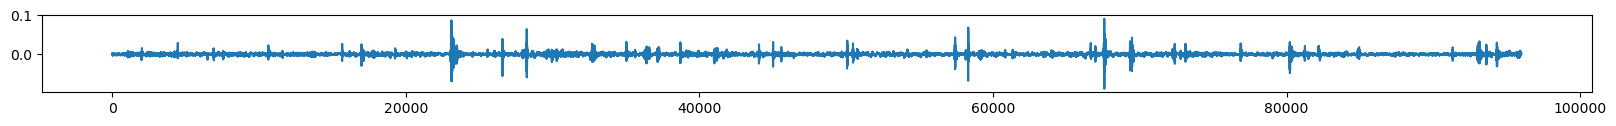

Finished epoch number 27 with a total of 10000 debug_seqs
 time: 2026-01-29 01:29:19.371935, epoch 28,  Loss: 0.3145
  Quantizer 0 Loss: 3.3351
  Quantizer 1 Loss: 3.7226
  Quantizer 2 Loss: 3.9431
  Quantizer 3 Loss: 4.0094
  Quantizer 4 Loss: 4.1324
  Quantizer 5 Loss: 4.1798
  Quantizer 6 Loss: 4.3043
  Quantizer 7 Loss: 4.4181
Latents embedded in 91 of the GRU input size of 128
Conditioning parameters embedded in 37 of the GRU input size of 128
DEVICE going in: model tensors cpu, enc_model cpu, c cpu
About toInitialize generator with c.shape = torch.Size([1])
params_seq.shape = torch.Size([10, 1])
plot the audio which has shape (96000,)


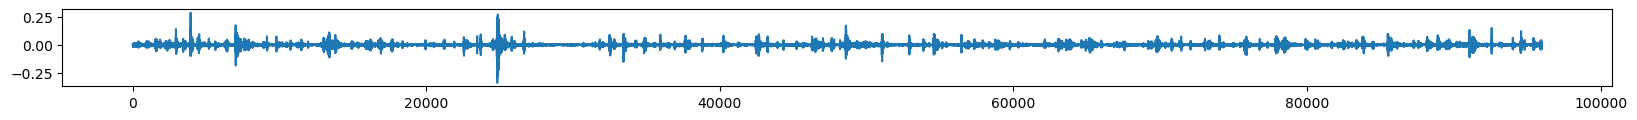

Finished epoch number 28 with a total of 10000 debug_seqs
 time: 2026-01-29 01:35:40.852793, epoch 29,  Loss: 0.2979
  Quantizer 0 Loss: 3.2969
  Quantizer 1 Loss: 3.6053
  Quantizer 2 Loss: 3.8218
  Quantizer 3 Loss: 3.8509
  Quantizer 4 Loss: 3.9601
  Quantizer 5 Loss: 4.0176
  Quantizer 6 Loss: 4.1253
  Quantizer 7 Loss: 4.2423
Latents embedded in 91 of the GRU input size of 128
Conditioning parameters embedded in 37 of the GRU input size of 128
DEVICE going in: model tensors cpu, enc_model cpu, c cpu
About toInitialize generator with c.shape = torch.Size([1])
params_seq.shape = torch.Size([10, 1])
plot the audio which has shape (96000,)


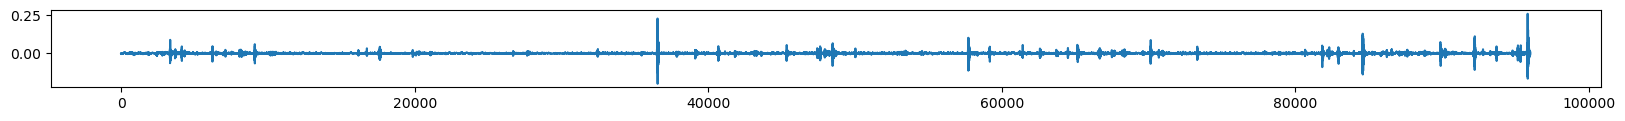

Finished epoch number 29 with a total of 10000 debug_seqs
 time: 2026-01-29 01:42:06.146439, epoch 30,  Loss: 0.2961
  Quantizer 0 Loss: 3.2793
  Quantizer 1 Loss: 3.5292
  Quantizer 2 Loss: 3.7324
  Quantizer 3 Loss: 3.7639
  Quantizer 4 Loss: 3.8675
  Quantizer 5 Loss: 3.9178
  Quantizer 6 Loss: 4.0162
  Quantizer 7 Loss: 4.1325
Latents embedded in 91 of the GRU input size of 128
Conditioning parameters embedded in 37 of the GRU input size of 128
DEVICE going in: model tensors cpu, enc_model cpu, c cpu
About toInitialize generator with c.shape = torch.Size([1])
params_seq.shape = torch.Size([10, 1])
plot the audio which has shape (96000,)


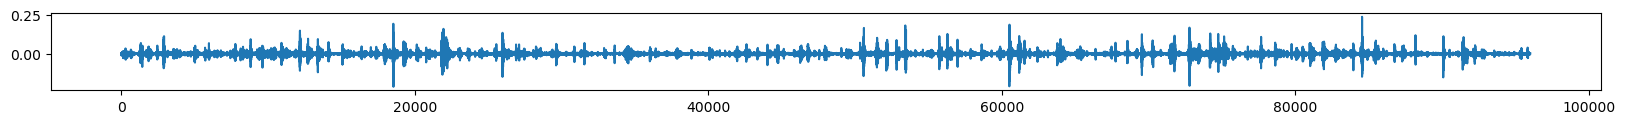

Finished epoch number 30 with a total of 10000 debug_seqs
 time: 2026-01-29 01:48:24.834030, epoch 31,  Loss: 0.2863
  Quantizer 0 Loss: 3.2629
  Quantizer 1 Loss: 3.5097
  Quantizer 2 Loss: 3.6865
  Quantizer 3 Loss: 3.7113
  Quantizer 4 Loss: 3.8089
  Quantizer 5 Loss: 3.8543
  Quantizer 6 Loss: 3.9461
  Quantizer 7 Loss: 4.0575
Latents embedded in 91 of the GRU input size of 128
Conditioning parameters embedded in 37 of the GRU input size of 128
DEVICE going in: model tensors cpu, enc_model cpu, c cpu
About toInitialize generator with c.shape = torch.Size([1])
params_seq.shape = torch.Size([10, 1])
plot the audio which has shape (96000,)


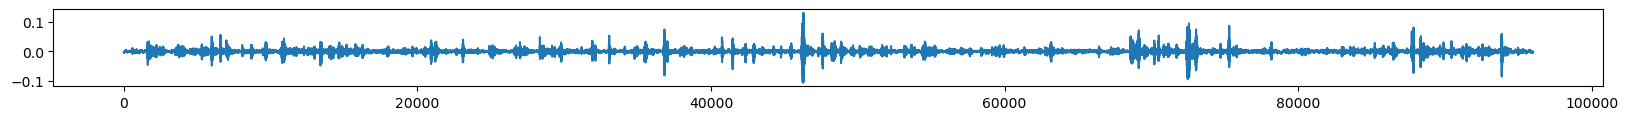

Finished epoch number 31 with a total of 10000 debug_seqs
 time: 2026-01-29 01:54:48.063387, epoch 32,  Loss: 0.2912
  Quantizer 0 Loss: 3.2500
  Quantizer 1 Loss: 3.4734
  Quantizer 2 Loss: 3.6496
  Quantizer 3 Loss: 3.6615
  Quantizer 4 Loss: 3.7471
  Quantizer 5 Loss: 3.7886
  Quantizer 6 Loss: 3.8744
  Quantizer 7 Loss: 3.9869
Latents embedded in 91 of the GRU input size of 128
Conditioning parameters embedded in 37 of the GRU input size of 128
DEVICE going in: model tensors cpu, enc_model cpu, c cpu
About toInitialize generator with c.shape = torch.Size([1])
params_seq.shape = torch.Size([10, 1])
plot the audio which has shape (96000,)


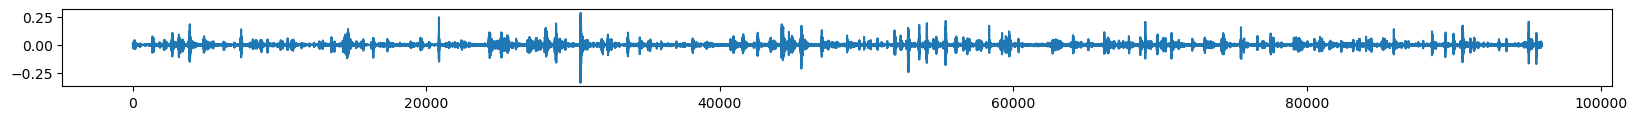

Finished epoch number 32 with a total of 10000 debug_seqs
 time: 2026-01-29 02:01:02.431953, epoch 33,  Loss: 0.2818
  Quantizer 0 Loss: 3.2348
  Quantizer 1 Loss: 3.4460
  Quantizer 2 Loss: 3.6046
  Quantizer 3 Loss: 3.6076
  Quantizer 4 Loss: 3.6899
  Quantizer 5 Loss: 3.7239
  Quantizer 6 Loss: 3.8029
  Quantizer 7 Loss: 3.9189
Latents embedded in 91 of the GRU input size of 128
Conditioning parameters embedded in 37 of the GRU input size of 128
DEVICE going in: model tensors cpu, enc_model cpu, c cpu
About toInitialize generator with c.shape = torch.Size([1])
params_seq.shape = torch.Size([10, 1])
plot the audio which has shape (96000,)


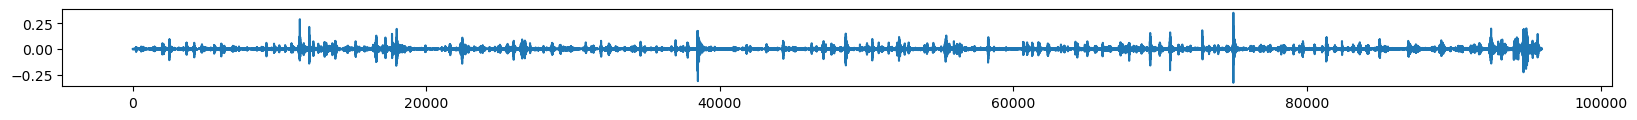

Finished epoch number 33 with a total of 10000 debug_seqs
 time: 2026-01-29 02:07:16.942999, epoch 34,  Loss: 0.2808
  Quantizer 0 Loss: 3.2267
  Quantizer 1 Loss: 3.4159
  Quantizer 2 Loss: 3.5687
  Quantizer 3 Loss: 3.5713
  Quantizer 4 Loss: 3.6553
  Quantizer 5 Loss: 3.6862
  Quantizer 6 Loss: 3.7582
  Quantizer 7 Loss: 3.8726
Latents embedded in 91 of the GRU input size of 128
Conditioning parameters embedded in 37 of the GRU input size of 128
DEVICE going in: model tensors cpu, enc_model cpu, c cpu
About toInitialize generator with c.shape = torch.Size([1])
params_seq.shape = torch.Size([10, 1])
plot the audio which has shape (96000,)


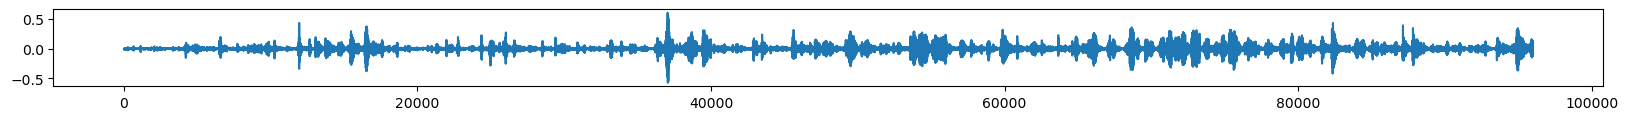

Finished epoch number 34 with a total of 10000 debug_seqs
 time: 2026-01-29 02:13:40.999968, epoch 35,  Loss: 0.2824
  Quantizer 0 Loss: 3.2256
  Quantizer 1 Loss: 3.4143
  Quantizer 2 Loss: 3.5575
  Quantizer 3 Loss: 3.5539
  Quantizer 4 Loss: 3.6346
  Quantizer 5 Loss: 3.6554
  Quantizer 6 Loss: 3.7257
  Quantizer 7 Loss: 3.8409
Latents embedded in 91 of the GRU input size of 128
Conditioning parameters embedded in 37 of the GRU input size of 128
DEVICE going in: model tensors cpu, enc_model cpu, c cpu
About toInitialize generator with c.shape = torch.Size([1])
params_seq.shape = torch.Size([10, 1])
plot the audio which has shape (96000,)


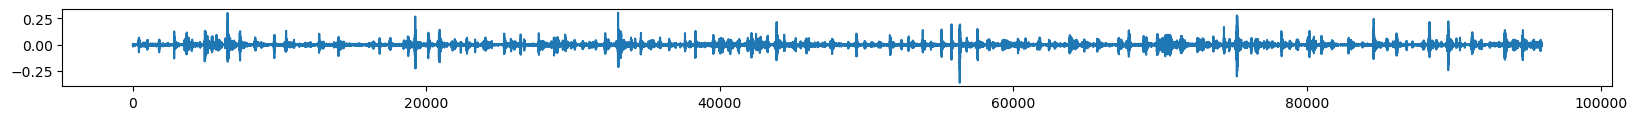

Finished epoch number 35 with a total of 10000 debug_seqs
 time: 2026-01-29 02:20:03.176659, epoch 36,  Loss: 0.2782
  Quantizer 0 Loss: 3.2129
  Quantizer 1 Loss: 3.3814
  Quantizer 2 Loss: 3.5236
  Quantizer 3 Loss: 3.5131
  Quantizer 4 Loss: 3.5881
  Quantizer 5 Loss: 3.6117
  Quantizer 6 Loss: 3.6768
  Quantizer 7 Loss: 3.7961
Latents embedded in 91 of the GRU input size of 128
Conditioning parameters embedded in 37 of the GRU input size of 128
DEVICE going in: model tensors cpu, enc_model cpu, c cpu
About toInitialize generator with c.shape = torch.Size([1])
params_seq.shape = torch.Size([10, 1])
plot the audio which has shape (96000,)


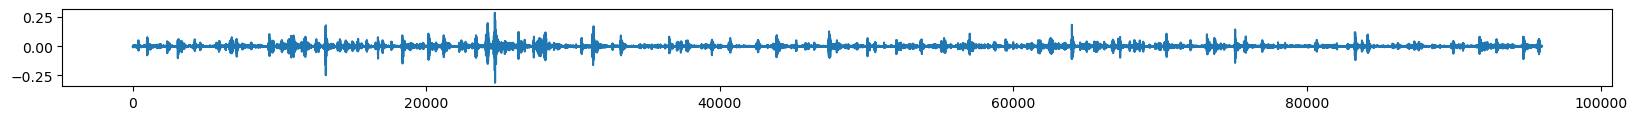

Finished epoch number 36 with a total of 10000 debug_seqs
 time: 2026-01-29 02:26:32.091793, epoch 37,  Loss: 0.2721
  Quantizer 0 Loss: 3.2062
  Quantizer 1 Loss: 3.3687
  Quantizer 2 Loss: 3.5042
  Quantizer 3 Loss: 3.4954
  Quantizer 4 Loss: 3.5644
  Quantizer 5 Loss: 3.5847
  Quantizer 6 Loss: 3.6508
  Quantizer 7 Loss: 3.7574
Latents embedded in 91 of the GRU input size of 128
Conditioning parameters embedded in 37 of the GRU input size of 128
DEVICE going in: model tensors cpu, enc_model cpu, c cpu
About toInitialize generator with c.shape = torch.Size([1])
params_seq.shape = torch.Size([10, 1])
plot the audio which has shape (96000,)


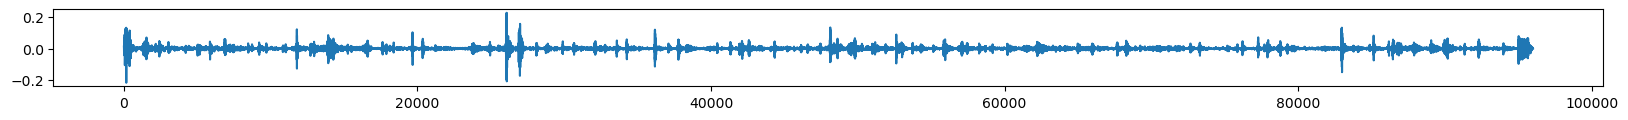

Finished epoch number 37 with a total of 10000 debug_seqs
 time: 2026-01-29 02:33:07.126249, epoch 38,  Loss: 0.2726
  Quantizer 0 Loss: 3.2007
  Quantizer 1 Loss: 3.3606
  Quantizer 2 Loss: 3.4870
  Quantizer 3 Loss: 3.4781
  Quantizer 4 Loss: 3.5438
  Quantizer 5 Loss: 3.5594
  Quantizer 6 Loss: 3.6233
  Quantizer 7 Loss: 3.7376
Latents embedded in 91 of the GRU input size of 128
Conditioning parameters embedded in 37 of the GRU input size of 128
DEVICE going in: model tensors cpu, enc_model cpu, c cpu
About toInitialize generator with c.shape = torch.Size([1])
params_seq.shape = torch.Size([10, 1])
plot the audio which has shape (96000,)


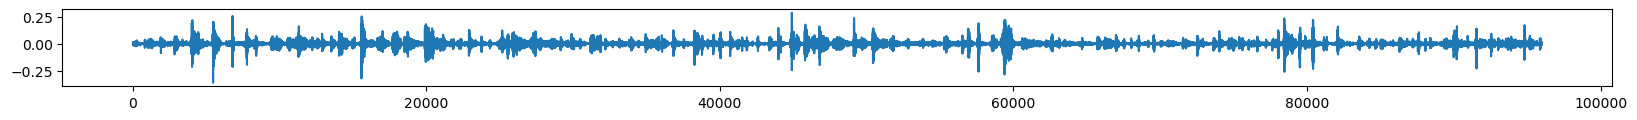

Finished epoch number 38 with a total of 10000 debug_seqs
 time: 2026-01-29 02:39:29.140413, epoch 39,  Loss: 0.2752
  Quantizer 0 Loss: 3.1950
  Quantizer 1 Loss: 3.3402
  Quantizer 2 Loss: 3.4706
  Quantizer 3 Loss: 3.4517
  Quantizer 4 Loss: 3.5162
  Quantizer 5 Loss: 3.5308
  Quantizer 6 Loss: 3.5901
  Quantizer 7 Loss: 3.6999
Latents embedded in 91 of the GRU input size of 128
Conditioning parameters embedded in 37 of the GRU input size of 128
DEVICE going in: model tensors cpu, enc_model cpu, c cpu
About toInitialize generator with c.shape = torch.Size([1])
params_seq.shape = torch.Size([10, 1])
plot the audio which has shape (96000,)


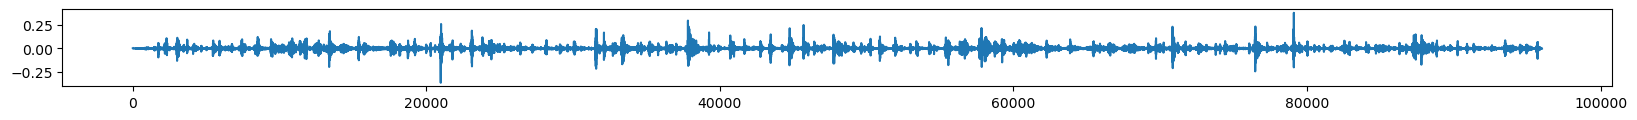

Finished epoch number 39 with a total of 10000 debug_seqs
 time: 2026-01-29 02:45:45.591776, epoch 40,  Loss: 0.2722
  Quantizer 0 Loss: 3.1870
  Quantizer 1 Loss: 3.3339
  Quantizer 2 Loss: 3.4551
  Quantizer 3 Loss: 3.4355
  Quantizer 4 Loss: 3.5021
  Quantizer 5 Loss: 3.5159
  Quantizer 6 Loss: 3.5725
  Quantizer 7 Loss: 3.6862
Latents embedded in 91 of the GRU input size of 128
Conditioning parameters embedded in 37 of the GRU input size of 128
DEVICE going in: model tensors cpu, enc_model cpu, c cpu
About toInitialize generator with c.shape = torch.Size([1])
params_seq.shape = torch.Size([10, 1])
plot the audio which has shape (96000,)


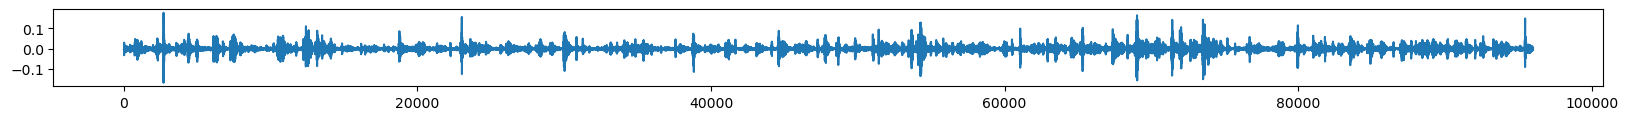

Finished epoch number 40 with a total of 10000 debug_seqs
 time: 2026-01-29 02:52:22.193556, epoch 41,  Loss: 0.2702
  Quantizer 0 Loss: 3.1840
  Quantizer 1 Loss: 3.3348
  Quantizer 2 Loss: 3.4459
  Quantizer 3 Loss: 3.4300
  Quantizer 4 Loss: 3.4916
  Quantizer 5 Loss: 3.5011
  Quantizer 6 Loss: 3.5604
  Quantizer 7 Loss: 3.6713
Latents embedded in 91 of the GRU input size of 128
Conditioning parameters embedded in 37 of the GRU input size of 128
DEVICE going in: model tensors cpu, enc_model cpu, c cpu
About toInitialize generator with c.shape = torch.Size([1])
params_seq.shape = torch.Size([10, 1])
plot the audio which has shape (96000,)


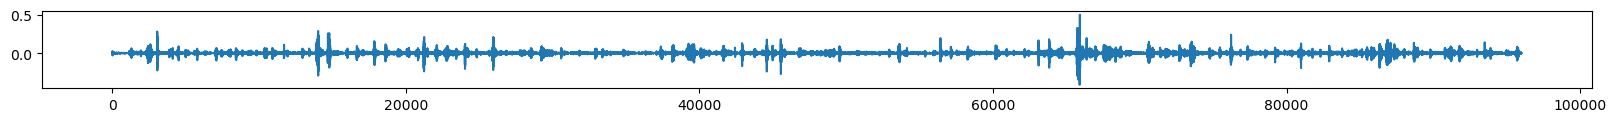

Finished epoch number 41 with a total of 10000 debug_seqs
 time: 2026-01-29 02:58:41.571179, epoch 42,  Loss: 0.2673
  Quantizer 0 Loss: 3.1735
  Quantizer 1 Loss: 3.3088
  Quantizer 2 Loss: 3.4239
  Quantizer 3 Loss: 3.3971
  Quantizer 4 Loss: 3.4627
  Quantizer 5 Loss: 3.4711
  Quantizer 6 Loss: 3.5223
  Quantizer 7 Loss: 3.6352
Latents embedded in 91 of the GRU input size of 128
Conditioning parameters embedded in 37 of the GRU input size of 128
DEVICE going in: model tensors cpu, enc_model cpu, c cpu
About toInitialize generator with c.shape = torch.Size([1])
params_seq.shape = torch.Size([10, 1])
plot the audio which has shape (96000,)


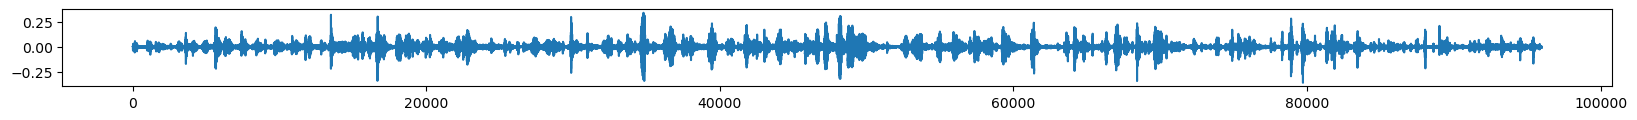

Finished epoch number 42 with a total of 10000 debug_seqs
 time: 2026-01-29 03:05:06.597680, epoch 43,  Loss: 0.2739
  Quantizer 0 Loss: 3.1695
  Quantizer 1 Loss: 3.2951
  Quantizer 2 Loss: 3.4149
  Quantizer 3 Loss: 3.3795
  Quantizer 4 Loss: 3.4435
  Quantizer 5 Loss: 3.4435
  Quantizer 6 Loss: 3.4969
  Quantizer 7 Loss: 3.6135
Latents embedded in 91 of the GRU input size of 128
Conditioning parameters embedded in 37 of the GRU input size of 128
DEVICE going in: model tensors cpu, enc_model cpu, c cpu
About toInitialize generator with c.shape = torch.Size([1])
params_seq.shape = torch.Size([10, 1])
plot the audio which has shape (96000,)


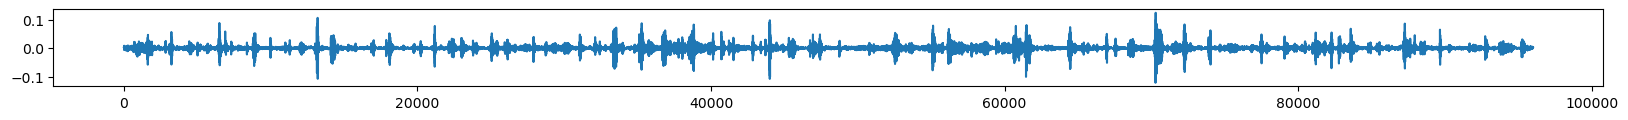

Finished epoch number 43 with a total of 10000 debug_seqs
 time: 2026-01-29 03:11:13.904896, epoch 44,  Loss: 0.2732
  Quantizer 0 Loss: 3.1715
  Quantizer 1 Loss: 3.2935
  Quantizer 2 Loss: 3.3989
  Quantizer 3 Loss: 3.3765
  Quantizer 4 Loss: 3.4315
  Quantizer 5 Loss: 3.4428
  Quantizer 6 Loss: 3.4897
  Quantizer 7 Loss: 3.6087
Latents embedded in 91 of the GRU input size of 128
Conditioning parameters embedded in 37 of the GRU input size of 128
DEVICE going in: model tensors cpu, enc_model cpu, c cpu
About toInitialize generator with c.shape = torch.Size([1])
params_seq.shape = torch.Size([10, 1])
plot the audio which has shape (96000,)


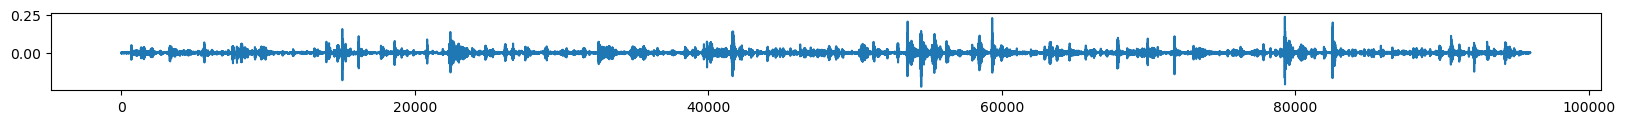

Finished epoch number 44 with a total of 10000 debug_seqs
 time: 2026-01-29 03:17:40.894343, epoch 45,  Loss: 0.2648
  Quantizer 0 Loss: 3.1685
  Quantizer 1 Loss: 3.2963
  Quantizer 2 Loss: 3.3987
  Quantizer 3 Loss: 3.3697
  Quantizer 4 Loss: 3.4254
  Quantizer 5 Loss: 3.4282
  Quantizer 6 Loss: 3.4725
  Quantizer 7 Loss: 3.5930
Latents embedded in 91 of the GRU input size of 128
Conditioning parameters embedded in 37 of the GRU input size of 128
DEVICE going in: model tensors cpu, enc_model cpu, c cpu
About toInitialize generator with c.shape = torch.Size([1])
params_seq.shape = torch.Size([10, 1])
plot the audio which has shape (96000,)


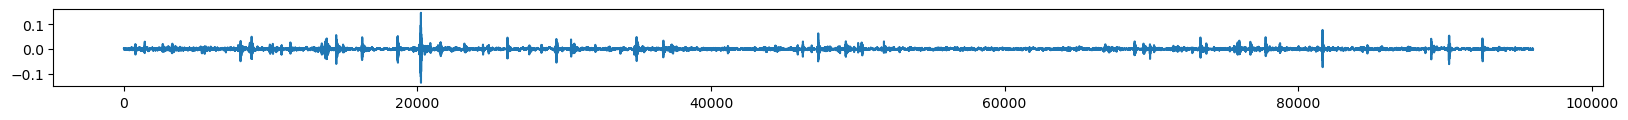

Finished epoch number 45 with a total of 10000 debug_seqs
 time: 2026-01-29 03:24:04.435181, epoch 46,  Loss: 0.2637
  Quantizer 0 Loss: 3.1552
  Quantizer 1 Loss: 3.2748
  Quantizer 2 Loss: 3.3791
  Quantizer 3 Loss: 3.3407
  Quantizer 4 Loss: 3.3957
  Quantizer 5 Loss: 3.4001
  Quantizer 6 Loss: 3.4469
  Quantizer 7 Loss: 3.5679
Latents embedded in 91 of the GRU input size of 128
Conditioning parameters embedded in 37 of the GRU input size of 128
DEVICE going in: model tensors cpu, enc_model cpu, c cpu
About toInitialize generator with c.shape = torch.Size([1])
params_seq.shape = torch.Size([10, 1])
plot the audio which has shape (96000,)


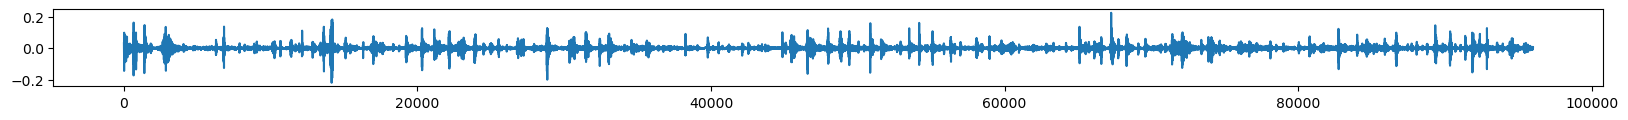

Finished epoch number 46 with a total of 10000 debug_seqs
 time: 2026-01-29 03:30:33.893532, epoch 47,  Loss: 0.2699
  Quantizer 0 Loss: 3.1544
  Quantizer 1 Loss: 3.2779
  Quantizer 2 Loss: 3.3688
  Quantizer 3 Loss: 3.3357
  Quantizer 4 Loss: 3.3925
  Quantizer 5 Loss: 3.3996
  Quantizer 6 Loss: 3.4467
  Quantizer 7 Loss: 3.5654
Latents embedded in 91 of the GRU input size of 128
Conditioning parameters embedded in 37 of the GRU input size of 128
DEVICE going in: model tensors cpu, enc_model cpu, c cpu
About toInitialize generator with c.shape = torch.Size([1])
params_seq.shape = torch.Size([10, 1])
plot the audio which has shape (96000,)


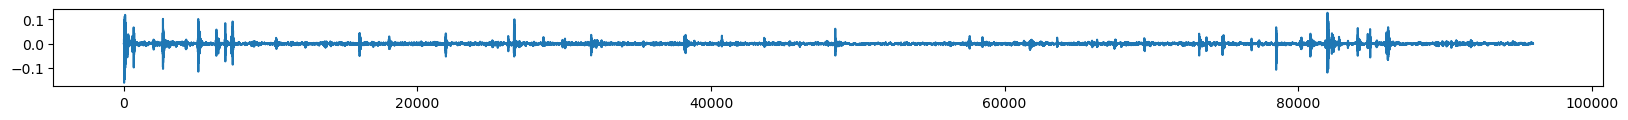

Finished epoch number 47 with a total of 10000 debug_seqs
 time: 2026-01-29 03:36:54.578178, epoch 48,  Loss: 0.2609
  Quantizer 0 Loss: 3.1519
  Quantizer 1 Loss: 3.2645
  Quantizer 2 Loss: 3.3669
  Quantizer 3 Loss: 3.3294
  Quantizer 4 Loss: 3.3834
  Quantizer 5 Loss: 3.3789
  Quantizer 6 Loss: 3.4270
  Quantizer 7 Loss: 3.5421
Latents embedded in 91 of the GRU input size of 128
Conditioning parameters embedded in 37 of the GRU input size of 128
DEVICE going in: model tensors cpu, enc_model cpu, c cpu
About toInitialize generator with c.shape = torch.Size([1])
params_seq.shape = torch.Size([10, 1])
plot the audio which has shape (96000,)


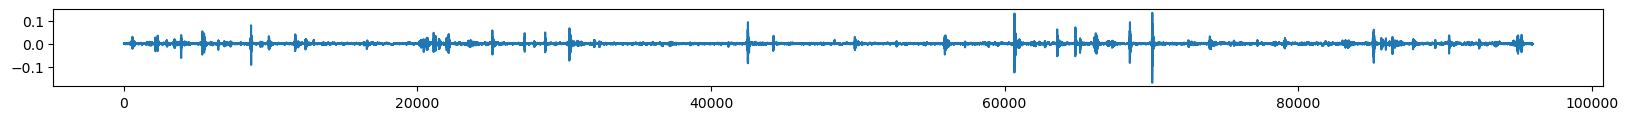

Finished epoch number 48 with a total of 10000 debug_seqs
 time: 2026-01-29 03:43:24.232491, epoch 49,  Loss: 0.2649
  Quantizer 0 Loss: 3.1451
  Quantizer 1 Loss: 3.2526
  Quantizer 2 Loss: 3.3448
  Quantizer 3 Loss: 3.3055
  Quantizer 4 Loss: 3.3591
  Quantizer 5 Loss: 3.3588
  Quantizer 6 Loss: 3.3967
  Quantizer 7 Loss: 3.5182
Latents embedded in 91 of the GRU input size of 128
Conditioning parameters embedded in 37 of the GRU input size of 128
DEVICE going in: model tensors cpu, enc_model cpu, c cpu
About toInitialize generator with c.shape = torch.Size([1])
params_seq.shape = torch.Size([10, 1])
plot the audio which has shape (96000,)


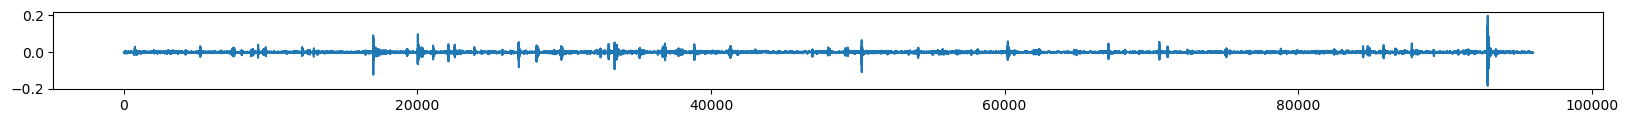

Finished epoch number 49 with a total of 10000 debug_seqs
 time: 2026-01-29 03:49:37.277893, epoch 50,  Loss: 0.2642
  Quantizer 0 Loss: 3.1379
  Quantizer 1 Loss: 3.2442
  Quantizer 2 Loss: 3.3289
  Quantizer 3 Loss: 3.2903
  Quantizer 4 Loss: 3.3463
  Quantizer 5 Loss: 3.3420
  Quantizer 6 Loss: 3.3812
  Quantizer 7 Loss: 3.4997
Latents embedded in 91 of the GRU input size of 128
Conditioning parameters embedded in 37 of the GRU input size of 128
DEVICE going in: model tensors cpu, enc_model cpu, c cpu
About toInitialize generator with c.shape = torch.Size([1])
params_seq.shape = torch.Size([10, 1])
plot the audio which has shape (96000,)


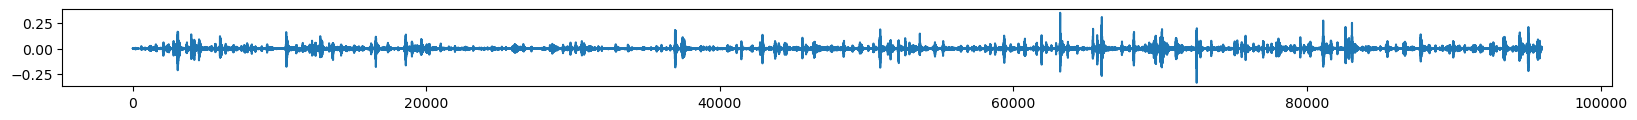

Saved checkpoint at epoch 50
Finished epoch number 50 with a total of 10000 debug_seqs
 time: 2026-01-29 03:54:27.026987, epoch 51,  Loss: 0.2285
  Quantizer 0 Loss: 3.0545
  Quantizer 1 Loss: 2.8999
  Quantizer 2 Loss: 2.9633
  Quantizer 3 Loss: 2.9380
  Quantizer 4 Loss: 2.9927
  Quantizer 5 Loss: 2.9910
  Quantizer 6 Loss: 3.0159
  Quantizer 7 Loss: 3.1297
Latents embedded in 91 of the GRU input size of 128
Conditioning parameters embedded in 37 of the GRU input size of 128
DEVICE going in: model tensors cpu, enc_model cpu, c cpu
About toInitialize generator with c.shape = torch.Size([1])
params_seq.shape = torch.Size([10, 1])
plot the audio which has shape (96000,)


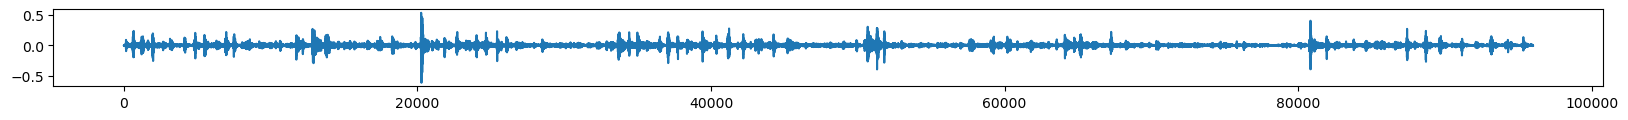

Finished epoch number 51 with a total of 10000 debug_seqs
 time: 2026-01-29 03:59:00.092995, epoch 52,  Loss: 0.2199
  Quantizer 0 Loss: 3.0071
  Quantizer 1 Loss: 2.7868
  Quantizer 2 Loss: 2.8009
  Quantizer 3 Loss: 2.7511
  Quantizer 4 Loss: 2.7887
  Quantizer 5 Loss: 2.7590
  Quantizer 6 Loss: 2.7652
  Quantizer 7 Loss: 2.8530
Latents embedded in 91 of the GRU input size of 128
Conditioning parameters embedded in 37 of the GRU input size of 128
DEVICE going in: model tensors cpu, enc_model cpu, c cpu
About toInitialize generator with c.shape = torch.Size([1])
params_seq.shape = torch.Size([10, 1])
plot the audio which has shape (96000,)


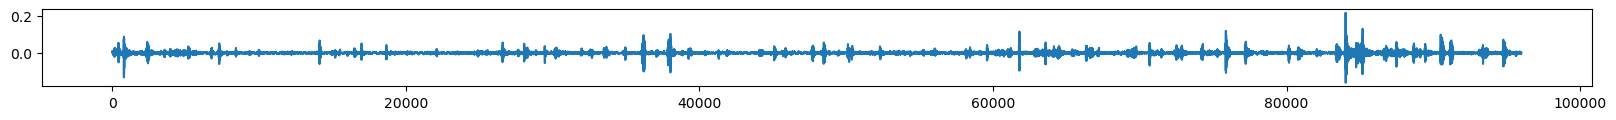

Finished epoch number 52 with a total of 10000 debug_seqs
 time: 2026-01-29 04:03:32.888479, epoch 53,  Loss: 0.2171
  Quantizer 0 Loss: 2.9889
  Quantizer 1 Loss: 2.7556
  Quantizer 2 Loss: 2.7537
  Quantizer 3 Loss: 2.6940
  Quantizer 4 Loss: 2.7260
  Quantizer 5 Loss: 2.6833
  Quantizer 6 Loss: 2.6760
  Quantizer 7 Loss: 2.7627
Latents embedded in 91 of the GRU input size of 128
Conditioning parameters embedded in 37 of the GRU input size of 128
DEVICE going in: model tensors cpu, enc_model cpu, c cpu
About toInitialize generator with c.shape = torch.Size([1])
params_seq.shape = torch.Size([10, 1])
plot the audio which has shape (96000,)


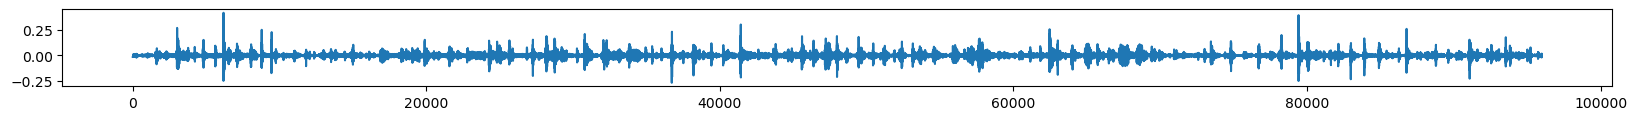

Finished epoch number 53 with a total of 10000 debug_seqs
 time: 2026-01-29 04:08:04.434808, epoch 54,  Loss: 0.2133
  Quantizer 0 Loss: 2.9775
  Quantizer 1 Loss: 2.7333
  Quantizer 2 Loss: 2.7239
  Quantizer 3 Loss: 2.6646
  Quantizer 4 Loss: 2.6928
  Quantizer 5 Loss: 2.6467
  Quantizer 6 Loss: 2.6323
  Quantizer 7 Loss: 2.7134
Latents embedded in 91 of the GRU input size of 128
Conditioning parameters embedded in 37 of the GRU input size of 128
DEVICE going in: model tensors cpu, enc_model cpu, c cpu
About toInitialize generator with c.shape = torch.Size([1])
params_seq.shape = torch.Size([10, 1])
plot the audio which has shape (96000,)


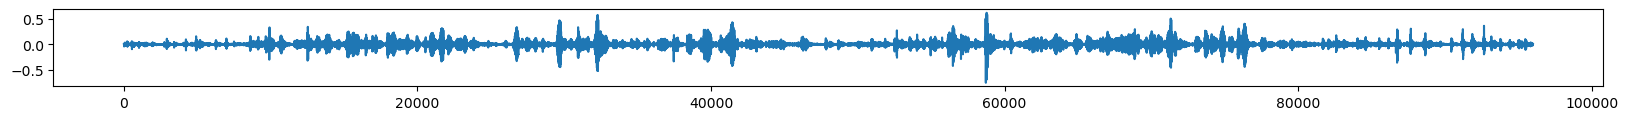

Finished epoch number 54 with a total of 10000 debug_seqs
 time: 2026-01-29 04:12:34.919090, epoch 55,  Loss: 0.2149
  Quantizer 0 Loss: 2.9634
  Quantizer 1 Loss: 2.7143
  Quantizer 2 Loss: 2.6990
  Quantizer 3 Loss: 2.6369
  Quantizer 4 Loss: 2.6616
  Quantizer 5 Loss: 2.6146
  Quantizer 6 Loss: 2.5995
  Quantizer 7 Loss: 2.6738
Latents embedded in 91 of the GRU input size of 128
Conditioning parameters embedded in 37 of the GRU input size of 128
DEVICE going in: model tensors cpu, enc_model cpu, c cpu
About toInitialize generator with c.shape = torch.Size([1])
params_seq.shape = torch.Size([10, 1])
plot the audio which has shape (96000,)


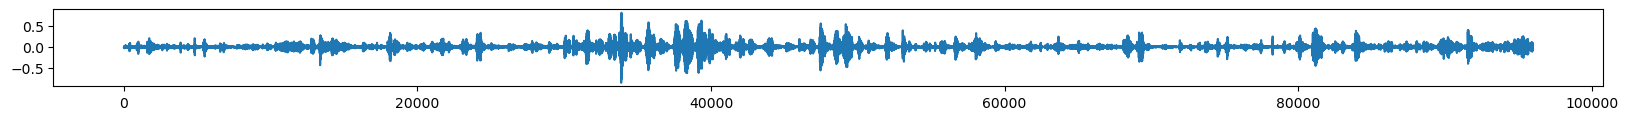

Finished epoch number 55 with a total of 10000 debug_seqs
 time: 2026-01-29 04:17:38.473582, epoch 56,  Loss: 0.2194
  Quantizer 0 Loss: 2.9587
  Quantizer 1 Loss: 2.7011
  Quantizer 2 Loss: 2.6871
  Quantizer 3 Loss: 2.6242
  Quantizer 4 Loss: 2.6455
  Quantizer 5 Loss: 2.5948
  Quantizer 6 Loss: 2.5805
  Quantizer 7 Loss: 2.6495
Latents embedded in 91 of the GRU input size of 128
Conditioning parameters embedded in 37 of the GRU input size of 128
DEVICE going in: model tensors cpu, enc_model cpu, c cpu
About toInitialize generator with c.shape = torch.Size([1])
params_seq.shape = torch.Size([10, 1])
plot the audio which has shape (96000,)


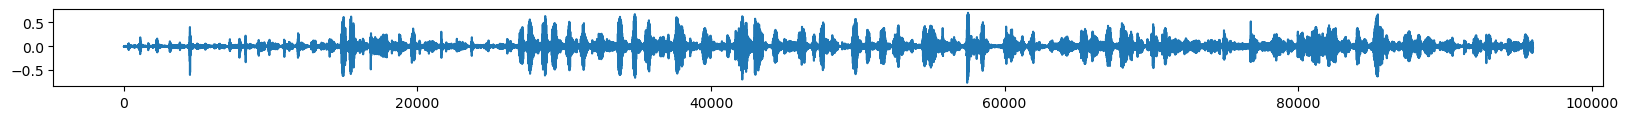

Finished epoch number 56 with a total of 10000 debug_seqs
 time: 2026-01-29 04:22:23.694836, epoch 57,  Loss: 0.2119
  Quantizer 0 Loss: 2.9531
  Quantizer 1 Loss: 2.6933
  Quantizer 2 Loss: 2.6771
  Quantizer 3 Loss: 2.6101
  Quantizer 4 Loss: 2.6287
  Quantizer 5 Loss: 2.5761
  Quantizer 6 Loss: 2.5534
  Quantizer 7 Loss: 2.6259
Latents embedded in 91 of the GRU input size of 128
Conditioning parameters embedded in 37 of the GRU input size of 128
DEVICE going in: model tensors cpu, enc_model cpu, c cpu
About toInitialize generator with c.shape = torch.Size([1])
params_seq.shape = torch.Size([10, 1])
plot the audio which has shape (96000,)


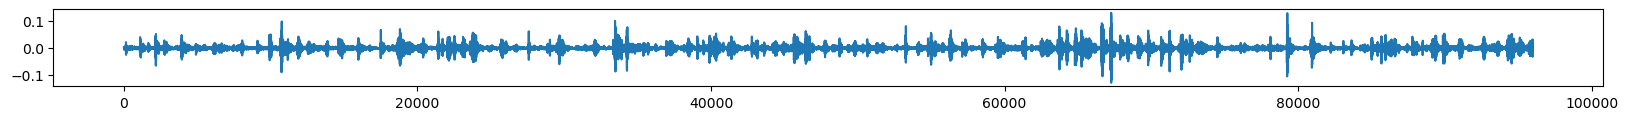

Finished epoch number 57 with a total of 10000 debug_seqs
 time: 2026-01-29 04:27:04.638976, epoch 58,  Loss: 0.2185
  Quantizer 0 Loss: 2.9443
  Quantizer 1 Loss: 2.6830
  Quantizer 2 Loss: 2.6550
  Quantizer 3 Loss: 2.5935
  Quantizer 4 Loss: 2.6181
  Quantizer 5 Loss: 2.5602
  Quantizer 6 Loss: 2.5352
  Quantizer 7 Loss: 2.6041
Latents embedded in 91 of the GRU input size of 128
Conditioning parameters embedded in 37 of the GRU input size of 128
DEVICE going in: model tensors cpu, enc_model cpu, c cpu
About toInitialize generator with c.shape = torch.Size([1])
params_seq.shape = torch.Size([10, 1])
plot the audio which has shape (96000,)


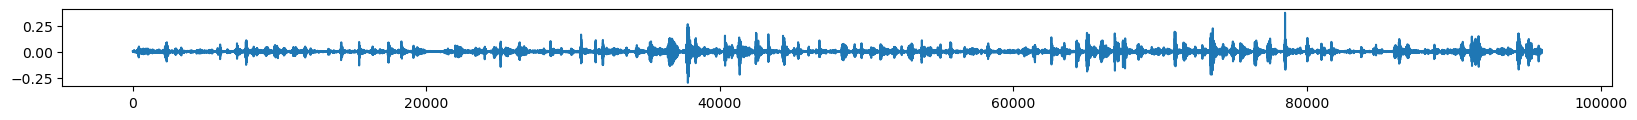

Finished epoch number 58 with a total of 10000 debug_seqs
 time: 2026-01-29 04:31:39.612955, epoch 59,  Loss: 0.2103
  Quantizer 0 Loss: 2.9378
  Quantizer 1 Loss: 2.6759
  Quantizer 2 Loss: 2.6514
  Quantizer 3 Loss: 2.5812
  Quantizer 4 Loss: 2.6077
  Quantizer 5 Loss: 2.5502
  Quantizer 6 Loss: 2.5323
  Quantizer 7 Loss: 2.5984
Latents embedded in 91 of the GRU input size of 128
Conditioning parameters embedded in 37 of the GRU input size of 128
DEVICE going in: model tensors cpu, enc_model cpu, c cpu
About toInitialize generator with c.shape = torch.Size([1])
params_seq.shape = torch.Size([10, 1])
plot the audio which has shape (96000,)


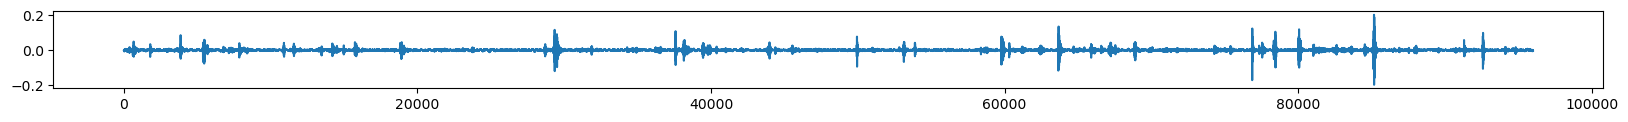

Finished epoch number 59 with a total of 10000 debug_seqs
 time: 2026-01-29 04:36:15.614679, epoch 60,  Loss: 0.2067
  Quantizer 0 Loss: 2.9331
  Quantizer 1 Loss: 2.6698
  Quantizer 2 Loss: 2.6389
  Quantizer 3 Loss: 2.5720
  Quantizer 4 Loss: 2.5979
  Quantizer 5 Loss: 2.5423
  Quantizer 6 Loss: 2.5135
  Quantizer 7 Loss: 2.5868
Latents embedded in 91 of the GRU input size of 128
Conditioning parameters embedded in 37 of the GRU input size of 128
DEVICE going in: model tensors cpu, enc_model cpu, c cpu
About toInitialize generator with c.shape = torch.Size([1])
params_seq.shape = torch.Size([10, 1])
plot the audio which has shape (96000,)


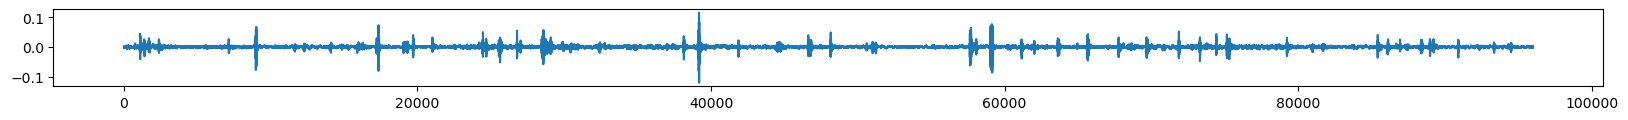

Finished epoch number 60 with a total of 10000 debug_seqs
 time: 2026-01-29 04:40:50.368978, epoch 61,  Loss: 0.2149
  Quantizer 0 Loss: 2.9226
  Quantizer 1 Loss: 2.6579
  Quantizer 2 Loss: 2.6277
  Quantizer 3 Loss: 2.5628
  Quantizer 4 Loss: 2.5914
  Quantizer 5 Loss: 2.5399
  Quantizer 6 Loss: 2.5088
  Quantizer 7 Loss: 2.5848
Latents embedded in 91 of the GRU input size of 128
Conditioning parameters embedded in 37 of the GRU input size of 128
DEVICE going in: model tensors cpu, enc_model cpu, c cpu
About toInitialize generator with c.shape = torch.Size([1])
params_seq.shape = torch.Size([10, 1])
plot the audio which has shape (96000,)


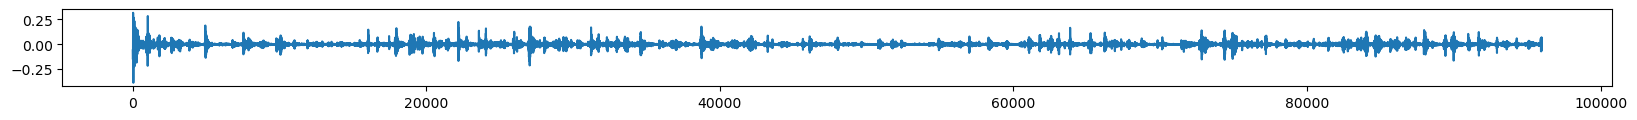

Finished epoch number 61 with a total of 10000 debug_seqs
 time: 2026-01-29 04:45:22.417171, epoch 62,  Loss: 0.2072
  Quantizer 0 Loss: 2.9191
  Quantizer 1 Loss: 2.6477
  Quantizer 2 Loss: 2.6177
  Quantizer 3 Loss: 2.5544
  Quantizer 4 Loss: 2.5810
  Quantizer 5 Loss: 2.5202
  Quantizer 6 Loss: 2.5011
  Quantizer 7 Loss: 2.5665
Latents embedded in 91 of the GRU input size of 128
Conditioning parameters embedded in 37 of the GRU input size of 128
DEVICE going in: model tensors cpu, enc_model cpu, c cpu
About toInitialize generator with c.shape = torch.Size([1])
params_seq.shape = torch.Size([10, 1])
plot the audio which has shape (96000,)


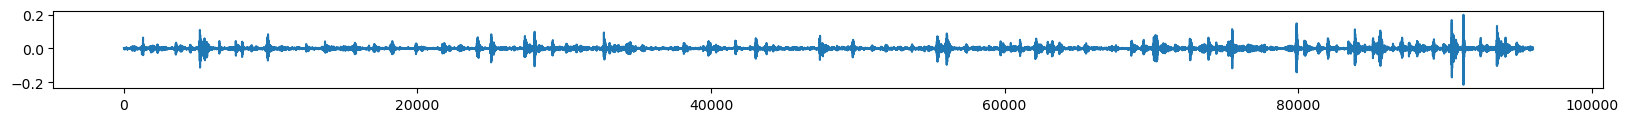

Finished epoch number 62 with a total of 10000 debug_seqs
 time: 2026-01-29 04:49:57.990496, epoch 63,  Loss: 0.2119
  Quantizer 0 Loss: 2.9202
  Quantizer 1 Loss: 2.6485
  Quantizer 2 Loss: 2.6165
  Quantizer 3 Loss: 2.5512
  Quantizer 4 Loss: 2.5749
  Quantizer 5 Loss: 2.5168
  Quantizer 6 Loss: 2.4913
  Quantizer 7 Loss: 2.5625
Latents embedded in 91 of the GRU input size of 128
Conditioning parameters embedded in 37 of the GRU input size of 128
DEVICE going in: model tensors cpu, enc_model cpu, c cpu
About toInitialize generator with c.shape = torch.Size([1])
params_seq.shape = torch.Size([10, 1])
plot the audio which has shape (96000,)


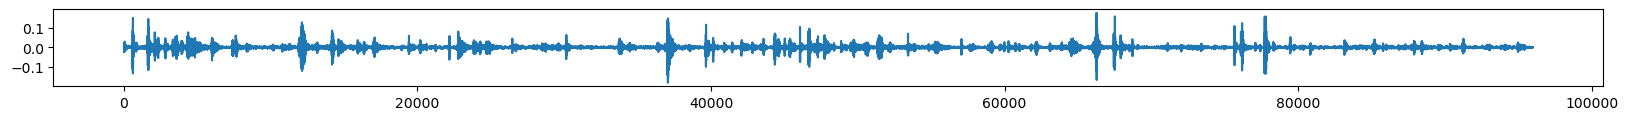

Finished epoch number 63 with a total of 10000 debug_seqs
 time: 2026-01-29 04:54:33.123781, epoch 64,  Loss: 0.2103
  Quantizer 0 Loss: 2.9094
  Quantizer 1 Loss: 2.6400
  Quantizer 2 Loss: 2.6069
  Quantizer 3 Loss: 2.5407
  Quantizer 4 Loss: 2.5659
  Quantizer 5 Loss: 2.5073
  Quantizer 6 Loss: 2.4815
  Quantizer 7 Loss: 2.5498
Latents embedded in 91 of the GRU input size of 128
Conditioning parameters embedded in 37 of the GRU input size of 128
DEVICE going in: model tensors cpu, enc_model cpu, c cpu
About toInitialize generator with c.shape = torch.Size([1])
params_seq.shape = torch.Size([10, 1])
plot the audio which has shape (96000,)


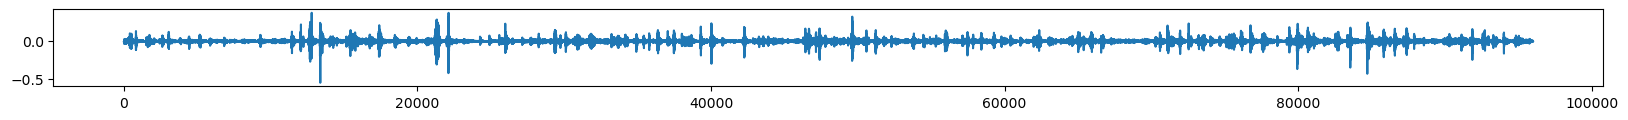

Finished epoch number 64 with a total of 10000 debug_seqs
 time: 2026-01-29 04:59:11.963343, epoch 65,  Loss: 0.2088
  Quantizer 0 Loss: 2.9041
  Quantizer 1 Loss: 2.6343
  Quantizer 2 Loss: 2.6057
  Quantizer 3 Loss: 2.5408
  Quantizer 4 Loss: 2.5638
  Quantizer 5 Loss: 2.5056
  Quantizer 6 Loss: 2.4831
  Quantizer 7 Loss: 2.5524
Latents embedded in 91 of the GRU input size of 128
Conditioning parameters embedded in 37 of the GRU input size of 128
DEVICE going in: model tensors cpu, enc_model cpu, c cpu
About toInitialize generator with c.shape = torch.Size([1])
params_seq.shape = torch.Size([10, 1])
plot the audio which has shape (96000,)


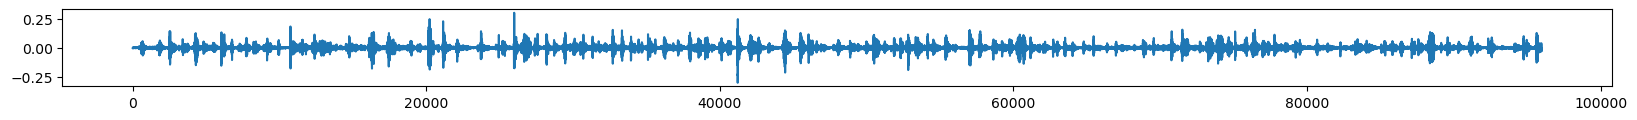

Finished epoch number 65 with a total of 10000 debug_seqs
 time: 2026-01-29 05:03:43.241778, epoch 66,  Loss: 0.2118
  Quantizer 0 Loss: 2.9015
  Quantizer 1 Loss: 2.6267
  Quantizer 2 Loss: 2.5932
  Quantizer 3 Loss: 2.5279
  Quantizer 4 Loss: 2.5550
  Quantizer 5 Loss: 2.4967
  Quantizer 6 Loss: 2.4685
  Quantizer 7 Loss: 2.5346
Latents embedded in 91 of the GRU input size of 128
Conditioning parameters embedded in 37 of the GRU input size of 128
DEVICE going in: model tensors cpu, enc_model cpu, c cpu
About toInitialize generator with c.shape = torch.Size([1])
params_seq.shape = torch.Size([10, 1])
plot the audio which has shape (96000,)


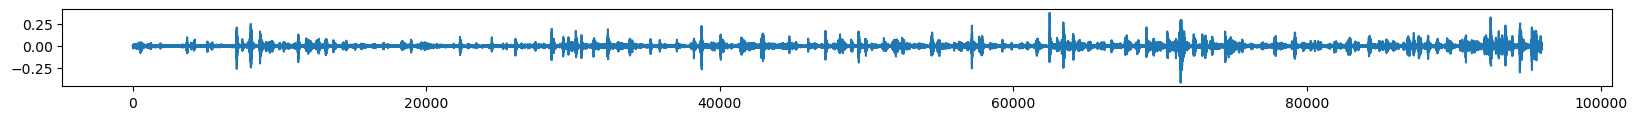

Finished epoch number 66 with a total of 10000 debug_seqs
 time: 2026-01-29 05:08:24.719078, epoch 67,  Loss: 0.2099
  Quantizer 0 Loss: 2.8928
  Quantizer 1 Loss: 2.6128
  Quantizer 2 Loss: 2.5859
  Quantizer 3 Loss: 2.5240
  Quantizer 4 Loss: 2.5457
  Quantizer 5 Loss: 2.4905
  Quantizer 6 Loss: 2.4642
  Quantizer 7 Loss: 2.5335
Latents embedded in 91 of the GRU input size of 128
Conditioning parameters embedded in 37 of the GRU input size of 128
DEVICE going in: model tensors cpu, enc_model cpu, c cpu
About toInitialize generator with c.shape = torch.Size([1])
params_seq.shape = torch.Size([10, 1])
plot the audio which has shape (96000,)


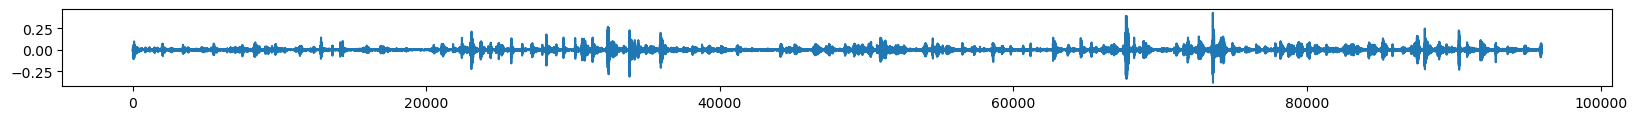

Finished epoch number 67 with a total of 10000 debug_seqs
 time: 2026-01-29 05:13:04.482692, epoch 68,  Loss: 0.2081
  Quantizer 0 Loss: 2.8906
  Quantizer 1 Loss: 2.6125
  Quantizer 2 Loss: 2.5846
  Quantizer 3 Loss: 2.5201
  Quantizer 4 Loss: 2.5445
  Quantizer 5 Loss: 2.4907
  Quantizer 6 Loss: 2.4609
  Quantizer 7 Loss: 2.5264
Latents embedded in 91 of the GRU input size of 128
Conditioning parameters embedded in 37 of the GRU input size of 128
DEVICE going in: model tensors cpu, enc_model cpu, c cpu
About toInitialize generator with c.shape = torch.Size([1])
params_seq.shape = torch.Size([10, 1])
plot the audio which has shape (96000,)


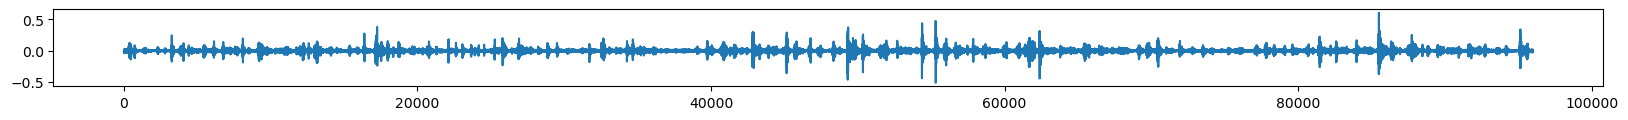

Finished epoch number 68 with a total of 10000 debug_seqs
 time: 2026-01-29 05:17:41.219802, epoch 69,  Loss: 0.2074
  Quantizer 0 Loss: 2.8798
  Quantizer 1 Loss: 2.6018
  Quantizer 2 Loss: 2.5665
  Quantizer 3 Loss: 2.5068
  Quantizer 4 Loss: 2.5317
  Quantizer 5 Loss: 2.4721
  Quantizer 6 Loss: 2.4452
  Quantizer 7 Loss: 2.5142
Latents embedded in 91 of the GRU input size of 128
Conditioning parameters embedded in 37 of the GRU input size of 128
DEVICE going in: model tensors cpu, enc_model cpu, c cpu
About toInitialize generator with c.shape = torch.Size([1])
params_seq.shape = torch.Size([10, 1])
plot the audio which has shape (96000,)


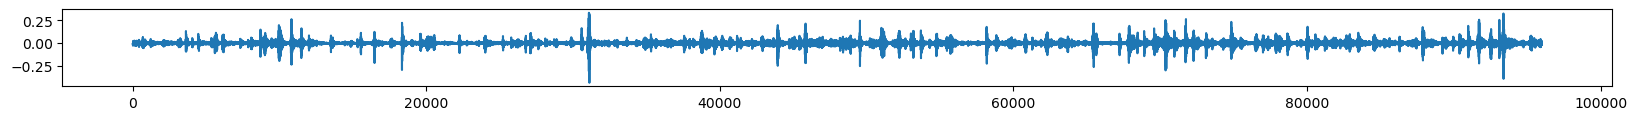

Finished epoch number 69 with a total of 10000 debug_seqs
 time: 2026-01-29 05:22:29.286825, epoch 70,  Loss: 0.2090
  Quantizer 0 Loss: 2.8732
  Quantizer 1 Loss: 2.5904
  Quantizer 2 Loss: 2.5581
  Quantizer 3 Loss: 2.4946
  Quantizer 4 Loss: 2.5259
  Quantizer 5 Loss: 2.4697
  Quantizer 6 Loss: 2.4401
  Quantizer 7 Loss: 2.5100
Latents embedded in 91 of the GRU input size of 128
Conditioning parameters embedded in 37 of the GRU input size of 128
DEVICE going in: model tensors cpu, enc_model cpu, c cpu
About toInitialize generator with c.shape = torch.Size([1])
params_seq.shape = torch.Size([10, 1])
plot the audio which has shape (96000,)


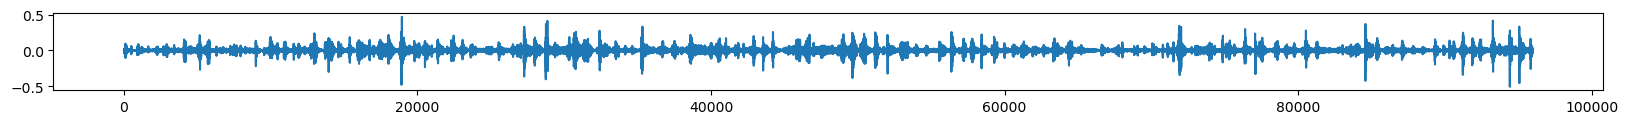

Finished epoch number 70 with a total of 10000 debug_seqs
 time: 2026-01-29 05:27:15.807304, epoch 71,  Loss: 0.2048
  Quantizer 0 Loss: 2.8687
  Quantizer 1 Loss: 2.5842
  Quantizer 2 Loss: 2.5528
  Quantizer 3 Loss: 2.4990
  Quantizer 4 Loss: 2.5197
  Quantizer 5 Loss: 2.4642
  Quantizer 6 Loss: 2.4317
  Quantizer 7 Loss: 2.5017
Latents embedded in 91 of the GRU input size of 128
Conditioning parameters embedded in 37 of the GRU input size of 128
DEVICE going in: model tensors cpu, enc_model cpu, c cpu
About toInitialize generator with c.shape = torch.Size([1])
params_seq.shape = torch.Size([10, 1])
plot the audio which has shape (96000,)


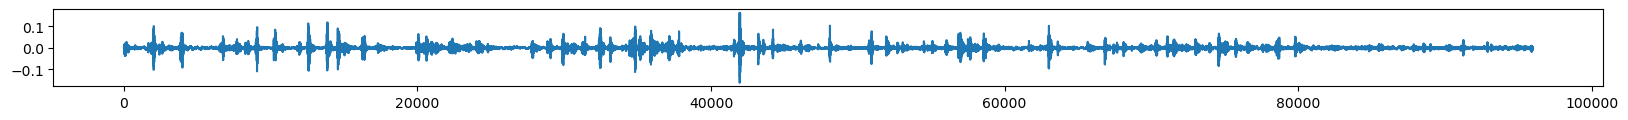

Finished epoch number 71 with a total of 10000 debug_seqs
 time: 2026-01-29 05:31:56.247653, epoch 72,  Loss: 0.2054
  Quantizer 0 Loss: 2.8650
  Quantizer 1 Loss: 2.5805
  Quantizer 2 Loss: 2.5502
  Quantizer 3 Loss: 2.4901
  Quantizer 4 Loss: 2.5147
  Quantizer 5 Loss: 2.4585
  Quantizer 6 Loss: 2.4337
  Quantizer 7 Loss: 2.5040
Latents embedded in 91 of the GRU input size of 128
Conditioning parameters embedded in 37 of the GRU input size of 128
DEVICE going in: model tensors cpu, enc_model cpu, c cpu
About toInitialize generator with c.shape = torch.Size([1])
params_seq.shape = torch.Size([10, 1])
plot the audio which has shape (96000,)


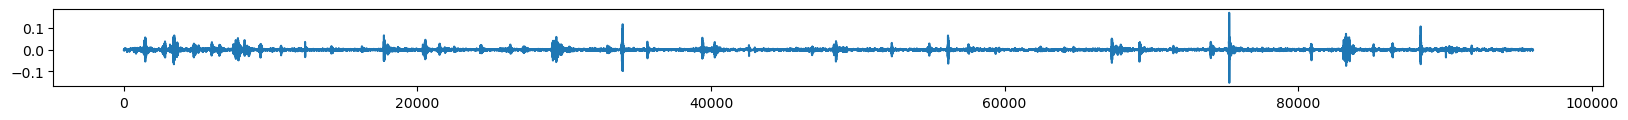

Finished epoch number 72 with a total of 10000 debug_seqs
 time: 2026-01-29 05:36:34.969510, epoch 73,  Loss: 0.2021
  Quantizer 0 Loss: 2.8541
  Quantizer 1 Loss: 2.5711
  Quantizer 2 Loss: 2.5400
  Quantizer 3 Loss: 2.4795
  Quantizer 4 Loss: 2.5075
  Quantizer 5 Loss: 2.4534
  Quantizer 6 Loss: 2.4264
  Quantizer 7 Loss: 2.4904
Latents embedded in 91 of the GRU input size of 128
Conditioning parameters embedded in 37 of the GRU input size of 128
DEVICE going in: model tensors cpu, enc_model cpu, c cpu
About toInitialize generator with c.shape = torch.Size([1])
params_seq.shape = torch.Size([10, 1])
plot the audio which has shape (96000,)


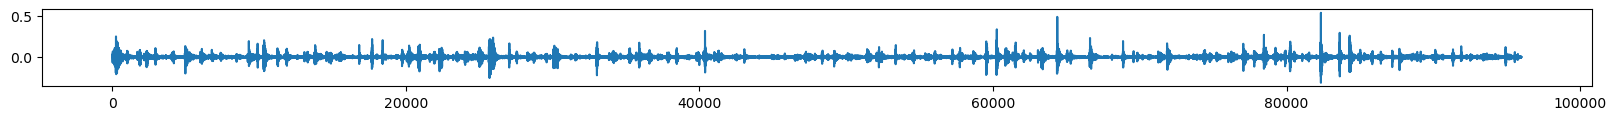

Finished epoch number 73 with a total of 10000 debug_seqs
 time: 2026-01-29 05:41:11.382168, epoch 74,  Loss: 0.2037
  Quantizer 0 Loss: 2.8586
  Quantizer 1 Loss: 2.5714
  Quantizer 2 Loss: 2.5392
  Quantizer 3 Loss: 2.4776
  Quantizer 4 Loss: 2.5047
  Quantizer 5 Loss: 2.4468
  Quantizer 6 Loss: 2.4203
  Quantizer 7 Loss: 2.4908
Latents embedded in 91 of the GRU input size of 128
Conditioning parameters embedded in 37 of the GRU input size of 128
DEVICE going in: model tensors cpu, enc_model cpu, c cpu
About toInitialize generator with c.shape = torch.Size([1])
params_seq.shape = torch.Size([10, 1])
plot the audio which has shape (96000,)


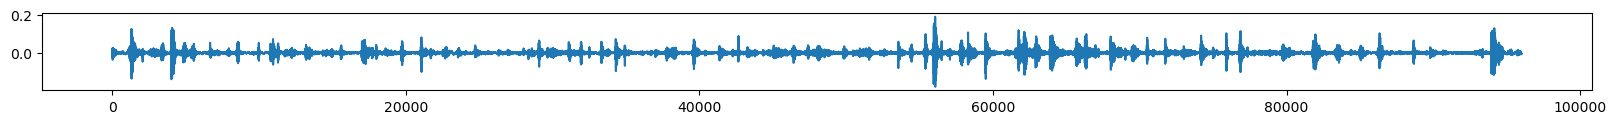

Finished epoch number 74 with a total of 10000 debug_seqs
 time: 2026-01-29 05:45:44.711373, epoch 75,  Loss: 0.2049
  Quantizer 0 Loss: 2.8505
  Quantizer 1 Loss: 2.5663
  Quantizer 2 Loss: 2.5326
  Quantizer 3 Loss: 2.4712
  Quantizer 4 Loss: 2.5034
  Quantizer 5 Loss: 2.4454
  Quantizer 6 Loss: 2.4130
  Quantizer 7 Loss: 2.4867
Latents embedded in 91 of the GRU input size of 128
Conditioning parameters embedded in 37 of the GRU input size of 128
DEVICE going in: model tensors cpu, enc_model cpu, c cpu
About toInitialize generator with c.shape = torch.Size([1])
params_seq.shape = torch.Size([10, 1])
plot the audio which has shape (96000,)


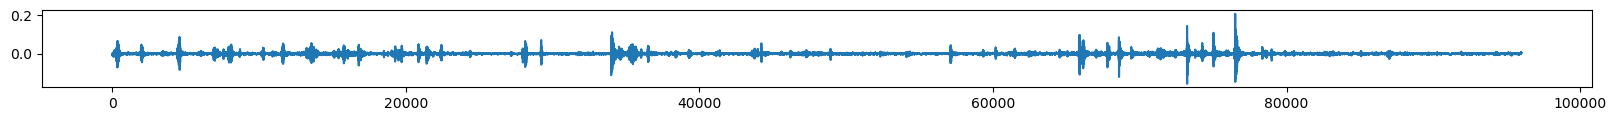

Saved checkpoint at epoch 75
Training time taken: 6:34:36
Saved checkpoint at epoch 75


'D:\\temp\\test2\\RNeNcodec\\dev_notebooks\\output\\20260128_231114_water_soft.newenvtest/checkpoints\\last_checkpoint.pt'

In [16]:
# Train!
#*************************************
enc_model.to(device)
list_of_losses = []

print('{:%Y-%m-%d %H:%M:%S} Starting training...'.format(datetime.now()))
start_time = time.monotonic()
#-------------------------------------------------------------------------------
for epoch in range(start_epoch, start_epoch+params['num_epochs']):
    train(rnn,enc_model,epoch)
#-------------------------------------------------------------------------------
writer.close()
elapsed_time = time.monotonic() - start_time
print('Training time taken:',time_taken(elapsed_time))

#Just make sure the final model gets saved
checkpoint_data = {
    'epoch': epoch+1,
    'model_state_dict': rnn.state_dict(),
    'optimizer_state_dict': optimizer.state_dict()
}
# Save numbered checkpoint
numbered_path = os.path.join(f"{out_dir}/checkpoints", f"checkpoint_{epoch+1}.pt")
torch.save(checkpoint_data, numbered_path)
print(f"Saved checkpoint at epoch {epoch+1}")
# Copy to "last" (much faster than saving twice)
last_path = os.path.join(f"{out_dir}/checkpoints", "last_checkpoint.pt")
shutil.copy2(numbered_path, last_path)


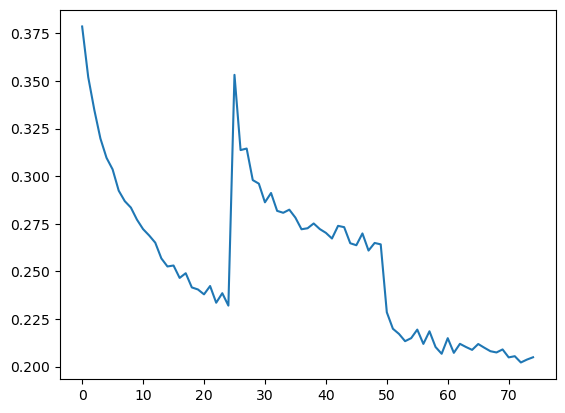

In [17]:
# Plot the loss over time
#*************************************
plt.figure()
plt.plot(list_of_losses)
plt.show()  # This will actually display the plot

In [18]:
list_of_losses

[0.37863376617431643,
 0.35200889587402345,
 0.3347677230834961,
 0.31977100372314454,
 0.3096533012390137,
 0.30356756210327146,
 0.29240104675292966,
 0.2868709945678711,
 0.2834958076477051,
 0.27713813781738283,
 0.2721880340576172,
 0.2688498115539551,
 0.26505964279174804,
 0.25680952072143554,
 0.25257001876831053,
 0.2530712699890137,
 0.24654747009277345,
 0.24902908325195314,
 0.24156538009643555,
 0.24049379348754882,
 0.23792478561401367,
 0.2423000717163086,
 0.23352123260498048,
 0.23853195190429688,
 0.23201148986816406,
 0.35323074340820315,
 0.3137070083618164,
 0.3145133972167969,
 0.2979456329345703,
 0.2960653877258301,
 0.28626777648925783,
 0.29116315841674806,
 0.2817764091491699,
 0.28077011108398436,
 0.28240453720092773,
 0.2782125473022461,
 0.2721162414550781,
 0.2726483917236328,
 0.2751597213745117,
 0.272220573425293,
 0.2702318572998047,
 0.2672601318359375,
 0.27390226364135745,
 0.27321802139282225,
 0.26477043151855467,
 0.2637228775024414,
 0.2699203